[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/07_canonical_forms_and_svd/first_principles.ipynb)

# Module 07 — Canonical Forms and the Singular Value Decomposition

## 1. Why This Module Exists

[Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb) answered one
question: when is there a basis in which $A$ acts diagonally? Symmetric matrices always have one.
General matrices do not.

Two gaps remain, and this module closes both.

**First gap: what is the best form when diagonalization fails?** A defective matrix has too few
eigenvectors to build a basis. The **Jordan canonical form** says exactly how much of diagonality
survives: a diagonal of eigenvalues plus a single superdiagonal of ones, and nothing else. It is a
complete invariant — two matrices are similar precisely when their Jordan forms agree up to the
order of the blocks.

**Second gap: rectangular matrices have no eigenvalues at all.** A map from $\mathbb{R}^n$ to
$\mathbb{R}^m$ with $m \neq n$ cannot fix a direction, because input and output live in different
spaces. The **singular value decomposition** replaces one basis by two, one on each side, and then
*every* matrix becomes diagonal.

Everything downstream — rank, the four fundamental subspaces, the operator and Frobenius norms, the
condition number, the pseudoinverse, the optimal low-rank approximation, the polar decomposition —
is read off a single SVD. That is why it is the one factorization worth computing when you do not
yet know what you need.

## 2. Intuition

Similarity $A \mapsto P^{-1}AP$ changes one basis and uses it on both sides. It preserves
eigenvalues, and it is the transformation the Jordan form is canonical for.

Two-sided orthogonal equivalence $A \mapsto U^{\top} A V$ changes the input basis and the output
basis independently. It destroys eigenvalues but preserves lengths, and it is the transformation
the SVD is canonical for.

The geometric statement is one sentence: **every matrix maps the unit sphere onto an ellipsoid.**

The right singular vectors $v_1, \dots, v_n$ are the orthonormal directions in the domain that get
sent to the principal axes of that ellipsoid. The left singular vectors $u_1, \dots, u_m$ are those
axis directions in the codomain, and the singular values $\sigma_1 \ge \dots \ge \sigma_r \gt 0$
are the semi-axis lengths:

$$
A v_i = \sigma_i u_i .
$$

Nothing here needs $A$ to be square, symmetric, or invertible. A rank-deficient matrix simply
flattens the ellipsoid: some semi-axes have length zero.

The Jordan picture is different in kind. A single Jordan block $J_k(0)$ is a *shift*: it pushes
$e_k \mapsto e_{k-1} \mapsto \dots \mapsto e_1 \mapsto 0$. A general nilpotent operator is nothing
but a disjoint union of such chains, and the Jordan form is the bookkeeping that finds them.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single random
generator used everywhere in this notebook, and prints the machine epsilon that later residual
claims are measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every reconstruction residual reported later is quoted as a multiple of this number.

The next cell draws the sphere-to-ellipsoid picture for the deliberately non-symmetric

$$
A = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix},
$$

whose singular values are the golden ratio $\varphi = (1+\sqrt5)/2$ and its reciprocal. The left
panel shows the unit circle in the domain with the two right singular vectors $v_1, v_2$; the right
panel shows the image ellipse with the semi-axes $\sigma_1 u_1$ and $\sigma_2 u_2$ drawn on it.

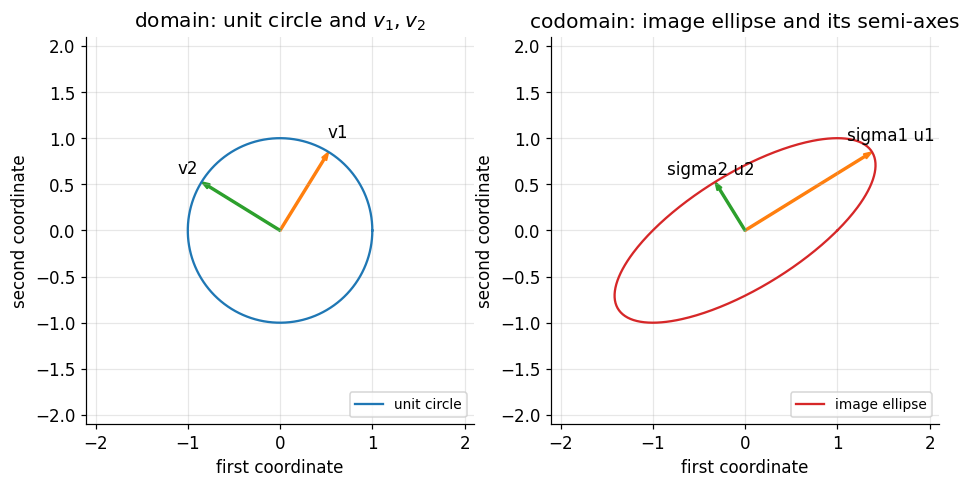

singular values      : [1.618 0.618]
golden ratio and 1/it: 1.618033988749895 0.6180339887498949
v1 . v2              : 0.0
u1 . u2              : 0.0
||A v1 - sigma1 u1|| : 0.0
eigenvalues of A     : [1. 1.]


In [2]:
Ash = np.array([[1.0, 1.0], [0.0, 1.0]])
Ush, sig_sh, Vtsh = np.linalg.svd(Ash)
Vsh = Vtsh.T

t = np.linspace(0.0, 2.0 * np.pi, 400)
circle = np.vstack([np.cos(t), np.sin(t)])
ellipse = Ash @ circle

fig, axes = plt.subplots(1, 2, figsize=(10.0, 5.0))

axes[0].plot(circle[0], circle[1], lw=1.5, label="unit circle")
for j in range(2):
    v = Vsh[:, j]
    axes[0].arrow(0, 0, v[0], v[1], width=0.02, length_includes_head=True,
                  color=f"C{j + 1}")
    axes[0].annotate(f"v{j + 1}", v * 1.18, ha="center")
axes[0].set_title("domain: unit circle and $v_1, v_2$")

axes[1].plot(ellipse[0], ellipse[1], lw=1.5, color="C3", label="image ellipse")
for j in range(2):
    w = sig_sh[j] * Ush[:, j]
    axes[1].arrow(0, 0, w[0], w[1], width=0.02, length_includes_head=True,
                  color=f"C{j + 1}")
    axes[1].annotate(f"sigma{j + 1} u{j + 1}", w * 1.15, ha="center")
axes[1].set_title("codomain: image ellipse and its semi-axes")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("first coordinate")
    ax.set_ylabel("second coordinate")
    ax.set_xlim(-2.1, 2.1)
    ax.set_ylim(-2.1, 2.1)
    ax.legend(loc="lower right", fontsize=9)
plt.show()

print("singular values      :", sig_sh)
print("golden ratio and 1/it:", (1 + np.sqrt(5)) / 2, (np.sqrt(5) - 1) / 2)
print("v1 . v2              :", Vsh[:, 0] @ Vsh[:, 1])
print("u1 . u2              :", Ush[:, 0] @ Ush[:, 1])
print("||A v1 - sigma1 u1|| :", np.linalg.norm(Ash @ Vsh[:, 0] - sig_sh[0] * Ush[:, 0]))
print("eigenvalues of A     :", np.linalg.eigvals(Ash))

The two arrows in each panel are orthogonal to machine precision, and the semi-axis lengths are the
singular values $1.618$ and $0.618$.

Note the last printed line: the *eigenvalues* of this matrix are $1, 1$, and they say nothing about
how far it stretches. The singular values do. For a non-normal matrix these are genuinely different
questions, and the SVD answers the metric one.

## 3. Definitions

Throughout, $A \in \mathbb{C}^{m \times n}$ or $\mathbb{R}^{m \times n}$, $A^{\ast}$ is the
conjugate transpose, $A^{\top}$ the plain transpose, and vectors are columns. Conventions follow
[the notation register](../../docs/notation.md): singular values and eigenvalues both descend,
norms are written $\lVert \cdot \rVert$, and $\Sigma$ inside a factorization is always the
singular-value matrix, never a covariance.

### Definition 3.1 — The three equivalences

Three relations on matrices appear in this module, and they preserve different things.

- $A$ and $B$ are **similar** when $B = P^{-1}AP$ for some invertible $P$. Similarity preserves
  the spectrum, the characteristic polynomial and the rank of every polynomial in $A$.
- $A$ and $B$ are **unitarily similar** when $B = U^{\ast}AU$ with $U$ unitary. This preserves the
  spectrum *and* all lengths.
- $A$ and $B$ are **unitarily equivalent** when $B = U^{\ast}AV$ with $U$ and $V$ unitary and
  **independent**. This destroys the spectrum but preserves the singular values.

The Jordan form is the canonical form for similarity; the SVD is the canonical form for unitary
equivalence.

### Definition 3.2 — Generalized eigenspace and index

Let $\lambda$ be an eigenvalue of $A \in \mathbb{C}^{n \times n}$ with algebraic multiplicity
$m_\lambda$. The **generalized eigenspace** is

$$
K_\lambda = \operatorname{Null}\bigl( (A - \lambda I)^{m_\lambda} \bigr) .
$$

The **index** of $\lambda$ is the smallest $q$ with
$\operatorname{Null}((A-\lambda I)^{q}) = \operatorname{Null}((A-\lambda I)^{q+1})$.

The ordinary eigenspace $E_\lambda = \operatorname{Null}(A - \lambda I)$ sits inside $K_\lambda$,
and the two coincide exactly when the index is $1$.

### Definition 3.3 — Jordan block and Jordan matrix

The **Jordan block** of size $k$ for $\lambda$ is the $k \times k$ matrix

$$
J_k(\lambda) = \lambda I_k + N_k, \qquad
N_k = \begin{pmatrix}
0 & 1 & & \\
& 0 & \ddots & \\
& & \ddots & 1 \\
& & & 0
\end{pmatrix},
$$

so $N_k e_1 = 0$ and $N_k e_j = e_{j-1}$ for $j \ge 2$. A **Jordan matrix** is a block diagonal
matrix $J = \operatorname{diag}\bigl(J_{k_1}(\mu_1), \dots, J_{k_p}(\mu_p)\bigr)$; the $\mu_i$ need
not be distinct.

A **Jordan chain of length $k$** for $\lambda$ is a tuple $(x_1, \dots, x_k)$ with $x_k \neq 0$,

$$
(A - \lambda I)x_1 = 0, \qquad (A - \lambda I)x_j = x_{j-1} \ \ (2 \le j \le k) .
$$

On the ordered basis $(x_1, \dots, x_k)$ the operator $A$ acts as $J_k(\lambda)$.

### Definition 3.4 — Singular values and the SVD

A **singular value decomposition** of $A \in \mathbb{R}^{m \times n}$ is a factorization

$$
A = U \Sigma V^{\top},
$$

with $U \in \mathbb{R}^{m \times m}$ and $V \in \mathbb{R}^{n \times n}$ orthogonal and
$\Sigma \in \mathbb{R}^{m \times n}$ having $\Sigma_{ii} = \sigma_i$ and all other entries zero,
where

$$
\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_{\min(m,n)} \ge 0 .
$$

The $\sigma_i$ are the **singular values**, the columns $u_i$ of $U$ the **left singular vectors**,
the columns $v_i$ of $V$ the **right singular vectors**. The complex statement replaces
$V^{\top}$ by $V^{\ast}$ and "orthogonal" by "unitary".

Three sizes are in circulation. With $r = \operatorname{rank}(A)$:

- **full**: as above, $U$ is $m \times m$ and $V$ is $n \times n$;
- **compact**: $A = U_r \Sigma_r V_r^{\top}$ keeping only the $r$ columns with $\sigma_i \gt 0$;
- **truncated at $k \lt r$**: $A_k = U_k \Sigma_k V_k^{\top} = \sum_{i=1}^{k} \sigma_i u_i v_i^{\top}$,
  which is an approximation, not a factorization of $A$.

### Definition 3.5 — Norms and the condition number

For $A$ with singular values $\sigma_1 \ge \dots \ge \sigma_r \gt 0$:

$$
\lVert A \rVert_{\mathrm{op}} = \sigma_1, \qquad
\lVert A \rVert_F = \Bigl( \sum_{i=1}^{r} \sigma_i^2 \Bigr)^{1/2}, \qquad
\lVert A \rVert_{\ast} = \sum_{i=1}^{r} \sigma_i .
$$

The third is the **nuclear** (or trace) norm. The **2-norm condition number** of a matrix of full
rank $n \le m$ is

$$
\kappa_2(A) = \frac{\sigma_1}{\sigma_n} .
$$

These are stated here as definitions of the right-hand sides; that $\sigma_1$ really is the
operator norm and that the Frobenius formula holds are proved as Theorem 4.4.

### Definition 3.6 — Moore-Penrose pseudoinverse

$X \in \mathbb{R}^{n \times m}$ is a **Moore-Penrose pseudoinverse** of $A \in \mathbb{R}^{m \times n}$
when all four **Penrose conditions** hold:

$$
\text{(P1)} \ AXA = A, \qquad
\text{(P2)} \ XAX = X, \qquad
\text{(P3)} \ (AX)^{\top} = AX, \qquad
\text{(P4)} \ (XA)^{\top} = XA .
$$

Note that the definition does not presuppose existence or uniqueness; both are proved as
Theorem 4.7. The pseudoinverse is written $A^{+}$.

### Definition 3.7 — Polar factors

A **right polar decomposition** of $A \in \mathbb{R}^{m \times n}$ with $m \ge n$ is a
factorization $A = QH$ in which $Q \in \mathbb{R}^{m \times n}$ has orthonormal columns
($Q^{\top}Q = I_n$) and $H \in \mathbb{R}^{n \times n}$ is symmetric positive semidefinite.

$Q$ is the rotational part and $H$ the stretch. The analogy is the polar form
$z = e^{i\theta}\lvert z \rvert$ of a complex number, with $H$ playing the role of the modulus.

## 4. Main Results

Theorems 4.1 and 4.2 are the canonical-forms half: existence of the Jordan form, and the rank
formula that both counts its blocks and makes it unique.

Theorems 4.3 to 4.8 are the SVD half: existence, what the factorization reads off, the perturbation
inequality for singular values, the optimal low-rank approximation, the pseudoinverse, and the polar
decomposition. Theorem 4.9 collects the two results quoted rather than proved, and Proposition 4.10
records the bridge that turns any symmetric eigenvalue theorem into a singular-value theorem.

### Theorem 4.1 — Jordan canonical form (existence)

Let $A \in \mathbb{C}^{n \times n}$. There exist an invertible $P \in \mathbb{C}^{n \times n}$ and a
Jordan matrix $J$ with

$$
A = P J P^{-1} .
$$

The diagonal entries of $J$ are the eigenvalues of $A$, each appearing $m_\lambda$ times.

**Hypotheses.** The field must be algebraically closed. Over $\mathbb{R}$ the statement is false:
the rotation $\left[\begin{smallmatrix}0 & -1 \\ 1 & 0\end{smallmatrix}\right]$ has no real
eigenvalue, so no real Jordan form. Over $\mathbb{C}$ nothing else is required — not
diagonalizability, not invertibility, not distinct eigenvalues.

Proved as Proof 5.1.

### Theorem 4.2 — Block-count formula and uniqueness of the Jordan form

Let $A \in \mathbb{C}^{n \times n}$, let $\lambda$ be an eigenvalue, and set
$r_j = \operatorname{rank}\bigl( (A - \lambda I)^{j} \bigr)$, so $r_0 = n$. Then the number of
Jordan blocks for $\lambda$ of size **at least** $j$ is

$$
b_{\ge j}(\lambda) = r_{j-1} - r_j ,
$$

and hence the number of blocks of size **exactly** $j$ is $r_{j-1} - 2r_j + r_{j+1}$.

Consequently the Jordan matrix $J$ of Theorem 4.1 is unique up to the order of its blocks, and two
matrices are similar if and only if they have the same Jordan form.

**Hypotheses.** None beyond those of Theorem 4.1. The formula uses only ranks, which are invariant
under similarity — that invariance is the whole reason it can prove uniqueness.

**Interpretation.** In particular $b_{\ge 1}(\lambda) = n - r_1 = g_\lambda$: the number of blocks
is the geometric multiplicity, and the total of their sizes is $m_\lambda$. A matrix is
diagonalizable exactly when every block has size $1$.

Proved as Proof 5.2.

### Theorem 4.3 — Existence of the singular value decomposition

Every $A \in \mathbb{R}^{m \times n}$ has a singular value decomposition $A = U\Sigma V^{\top}$ in
the sense of Definition 3.4. The same holds over $\mathbb{C}$ with unitary factors.

**Hypotheses.** None whatsoever. $A$ may be rectangular, rank-deficient, non-normal or zero. This
absence of hypotheses is the reason the SVD, and not the eigendecomposition, is the universal
factorization.

Two independent proofs are given: Proof 5.3, algebraic, via the spectral theorem applied to
$A^{\top}A$; and Proof 5.4, geometric, by maximizing $\lVert Ax \rVert$ over the unit sphere.

### Theorem 4.4 — What the SVD reads off

Let $A = U \Sigma V^{\top}$ with $r$ positive singular values. Then:

1. $\operatorname{rank}(A) = r$;
2. $\operatorname{Col}(A) = \operatorname{span}(u_1, \dots, u_r)$ and
   $\operatorname{Null}(A) = \operatorname{span}(v_{r+1}, \dots, v_n)$, with
   $\operatorname{Col}(A^{\top}) = \operatorname{span}(v_1, \dots, v_r)$ and
   $\operatorname{Null}(A^{\top}) = \operatorname{span}(u_{r+1}, \dots, u_m)$;
3. $A^{\top}A \, v_i = \sigma_i^2 v_i$ and $A A^{\top} u_i = \sigma_i^2 u_i$;
4. $\lVert A \rVert_{\mathrm{op}} = \sigma_1$ and $\lVert A \rVert_F^2 = \sum_i \sigma_i^2$;
5. the singular values are **unique**; the singular vectors are unique up to a sign when the
   $\sigma_i$ are distinct and positive, and up to an orthogonal mixing inside each repeated
   singular value.

**Hypotheses.** Only that $A = U\Sigma V^{\top}$ is an SVD. Statement 5 needs the singular values
listed in descending order, which Definition 3.4 imposes.

Proved as Proof 5.5.

### Theorem 4.5 — Weyl and Mirsky inequalities for singular values

Let $X, Y \in \mathbb{R}^{m \times n}$ and write $\sigma_i(\cdot)$ for the $i$-th largest singular
value, with $\sigma_i = 0$ for $i \gt \min(m,n)$. For all $i, j \ge 1$ with
$i + j - 1 \le \min(m, n)$,

$$
\sigma_{i+j-1}(X + Y) \;\le\; \sigma_i(X) + \sigma_j(Y) .
$$

Taking $j = 1$ gives **Weyl's inequality for singular values**,

$$
\lvert \sigma_i(X + Y) - \sigma_i(X) \rvert \;\le\; \lVert Y \rVert_{\mathrm{op}} .
$$

**Hypotheses.** Only that $X$ and $Y$ have the same shape. No symmetry, no rank condition.

**Interpretation.** Singular values are $1$-Lipschitz in the operator norm — perfectly conditioned,
with no amplification factor. The general $(i,j)$ form is the sharper statement that a
*low-rank* perturbation displaces the spectrum only by an index shift, and it is the tool that
makes the Frobenius half of Theorem 4.6 come out.

Proved as Proof 5.6.

### Theorem 4.6 — Eckart-Young-Mirsky

Let $A \in \mathbb{R}^{m \times n}$ have singular values $\sigma_1 \ge \dots \ge \sigma_p \ge 0$,
$p = \min(m,n)$, and let $A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^{\top}$ be the truncated SVD. For
every $k \lt \operatorname{rank}(A)$,

$$
\min_{\operatorname{rank}(B) \le k} \lVert A - B \rVert_{\mathrm{op}} = \lVert A - A_k \rVert_{\mathrm{op}} = \sigma_{k+1},
$$

$$
\min_{\operatorname{rank}(B) \le k} \lVert A - B \rVert_{F} = \lVert A - A_k \rVert_{F} = \Bigl( \sum_{i \gt k} \sigma_i^2 \Bigr)^{1/2} .
$$

**Hypotheses.** The minimum runs over *all* matrices of rank at most $k$, with no structure
imposed. The norms must be the operator or Frobenius norm; the result is in fact true for every
unitarily invariant norm, which is Mirsky's generalization.

**Interpretation.** The best rank-$k$ approximation is obtained by simply discarding the small
singular values, and the error is exactly what was discarded. Nothing cleverer exists.

Proved as Proof 5.7. Note that the truncation $A_k$ is optimal but **not unique**: when
$\sigma_k = \sigma_{k+1}$, other minimizers exist.

### Theorem 4.7 — Moore-Penrose pseudoinverse

Every $A \in \mathbb{R}^{m \times n}$ has exactly one matrix $A^{+}$ satisfying the four Penrose
conditions of Definition 3.6, namely

$$
A^{+} = V \Sigma^{+} U^{\top}, \qquad
\Sigma^{+}_{ii} = \begin{cases} 1/\sigma_i & \sigma_i \gt 0 \\ 0 & \sigma_i = 0 \end{cases}
$$

with $\Sigma^{+} \in \mathbb{R}^{n \times m}$. Moreover, for every $b \in \mathbb{R}^m$ the vector
$x^{\star} = A^{+}b$ is the unique minimizer of $\lVert x \rVert_2$ among all minimizers of
$\lVert Ax - b \rVert_2$.

**Hypotheses.** None. In particular $A$ need not have full rank; the convention
$0 \mapsto 0$ in $\Sigma^{+}$ is what makes the four conditions hold, and it is not an arbitrary
choice — Proof 5.8 shows any other choice violates (P1).

**Interpretation.** $AA^{+}$ is the orthogonal projector onto $\operatorname{Col}(A)$ and
$A^{+}A$ the orthogonal projector onto $\operatorname{Col}(A^{\top})$. The pseudoinverse solves
$Ax = b$ when it is solvable and does the least-squares thing when it is not.

Proved as Proof 5.8.

### Theorem 4.8 — Polar decomposition and the nearest orthogonal matrix

Let $A \in \mathbb{R}^{m \times n}$ with $m \ge n$ and $A = U\Sigma V^{\top}$ its SVD, and write
$U_n$ for the first $n$ columns of $U$. Then

$$
A = QH, \qquad Q = U_n V^{\top}, \qquad H = V \Sigma_n V^{\top} = (A^{\top}A)^{1/2},
$$

with $Q^{\top}Q = I_n$ and $H \succeq 0$. The factor $H$ is always unique; $Q$ is unique if and only
if $\operatorname{rank}(A) = n$.

Furthermore, for square $A$ this same $Q$ solves the **orthogonal Procrustes problem**

$$
Q \in \operatorname*{arg\,min}_{W^{\top}W = I} \lVert A - W \rVert_F,
\qquad \lVert A - Q \rVert_F^2 = \sum_{i=1}^{n} (\sigma_i - 1)^2 .
$$

**Hypotheses.** $m \ge n$ is needed for $Q^{\top}Q = I_n$; for $m \lt n$ use the left polar form
$A = H'Q'$ instead. Uniqueness of $Q$ fails exactly at rank deficiency, because the singular
directions with $\sigma_i = 0$ carry no information about where $Q$ should send them.

Proved as Proof 5.9.

### Theorem 4.9 (cited, not proved here) — randomized range finding and subspace perturbation

**Randomized range finder.** Let $\Omega \in \mathbb{R}^{n \times (k+p)}$ have i.i.d. standard
Gaussian entries with $k \ge 2$ and $p \ge 2$, let $Y = A\Omega$ and let $Q$ be an orthonormal
basis of $\operatorname{Col}(Y)$. Then

$$
\mathbb{E} \, \lVert A - QQ^{\top}A \rVert_F \;\le\; \Bigl(1 + \frac{k}{p-1}\Bigr)^{1/2} \Bigl( \sum_{i \gt k} \sigma_i^2 \Bigr)^{1/2} .
$$

Source: Halko, Martinsson and Tropp, "Finding structure with randomness", *SIAM Review* **53**(2),
2011, Theorem 10.5 (algorithm 4.1, with the power-iteration variant as Algorithm 4.3). The
deterministic half of that proof is set as Problem L3.8 of
[exercises.ipynb](exercises.ipynb).

**Wedin's $\sin\Theta$ theorem.** If $\widetilde{A} = A + E$ and the singular values of $A$ inside
the retained block are separated from those outside it by a gap $\delta \gt 0$, then the angle
between the corresponding singular subspaces obeys

$$
\max \bigl\{ \lVert \sin \Theta_U \rVert_F, \ \lVert \sin \Theta_V \rVert_F \bigr\}
\;\le\; \frac{\sqrt{2}\, \lVert E \rVert_F}{\delta} .
$$

Source: Wedin, "Perturbation bounds in connection with singular value decomposition",
*BIT* **12**(1), 1972, 99-111; see also Stewart and Sun, *Matrix Perturbation Theory*,
Theorem V.4.4.

**Why these are quoted and not proved.** Both need machinery this module does not build: Gaussian
matrix moment bounds for the first, and a two-sided $CS$-decomposition argument for the second. The
statement of Theorem 4.5 is the perturbation result this module does prove in full, and it is what
Section 7 measures.

### Proposition 4.10 — The Hermitian dilation

For $A \in \mathbb{R}^{m \times n}$ with singular values $\sigma_1 \ge \dots \ge \sigma_p$,
$p = \min(m,n)$, the symmetric matrix

$$
S = \begin{pmatrix} 0 & A \\ A^{\top} & 0 \end{pmatrix} \in \mathbb{R}^{(m+n) \times (m+n)}
$$

has spectrum $\lbrace +\sigma_1, -\sigma_1, \dots, +\sigma_p, -\sigma_p \rbrace$ together with
$\lvert m - n \rvert$ further zeros.

**Hypotheses.** None. $S$ is symmetric by construction whatever $A$ is, which is the point.

**Interpretation.** Every theorem about eigenvalues of symmetric matrices becomes a theorem about
singular values by passing to $S$, and the passage is linear in $A$. Applying Weyl's eigenvalue
inequality ([Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb),
Theorem 4.6) to $S$ is a third route to Theorem 4.5.

Proved as Proof 5.10.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, Jordan canonical form)

Write the characteristic polynomial with its distinct roots,

$$
p_A(z) = \prod_{i=1}^{s} (z - \lambda_i)^{m_i}, \qquad \sum_{i=1}^{s} m_i = n,
$$

which the fundamental theorem of algebra guarantees over $\mathbb{C}$.

**Step 1 — primary decomposition.** Put $q_i(z) = p_A(z) / (z - \lambda_i)^{m_i}$.

The $q_i$ have no common root: $q_i(\lambda_i) \neq 0$ while $q_l(\lambda_i) = 0$ for every
$l \neq i$. Their greatest common divisor is therefore $1$, and Bezout's identity for polynomials
supplies $h_1, \dots, h_s$ with

$$
\sum_{i=1}^{s} h_i(z) \, q_i(z) = 1 .
$$

Define $P_i = h_i(A) q_i(A)$, so that $\sum_i P_i = I$. Because
$(z - \lambda_i)^{m_i} q_i(z) = p_A(z)$ and $p_A(A) = 0$ by the Cayley-Hamilton theorem
([Module 05](../05_determinants_trace_and_matrix_polynomials/first_principles.ipynb)),

$$
(A - \lambda_i I)^{m_i} P_i = h_i(A) \, p_A(A) = 0 ,
$$

so $\operatorname{Col}(P_i) \subseteq K_{\lambda_i}$. Since $\sum_i P_i = I$, every $x$ satisfies
$x = \sum_i P_i x$, and therefore

$$
\mathbb{C}^n = K_{\lambda_1} + \dots + K_{\lambda_s} .
$$

The sum is direct. If $x \in K_{\lambda_j}$ then for $i \neq j$ the polynomial $q_i$ contains the
factor $(z-\lambda_j)^{m_j}$, so $q_i(A)x = 0$ and hence $P_i x = 0$; consequently $P_j x = x$.
Applying $P_j$ to a relation $x_1 + \dots + x_s = 0$ with $x_i \in K_{\lambda_i}$ therefore returns
$x_j = 0$.

Each $K_{\lambda_i}$ is $A$-invariant, because $A$ commutes with $(A - \lambda_i I)^{m_i}$.

**Step 2 — the generalized eigenspaces have the right dimension.** On $K_{\lambda_i}$ the operator
$N_i = (A - \lambda_i I)\big|_{K_{\lambda_i}}$ is nilpotent by construction, so $\lambda_i$ is the
only eigenvalue of $A\big|_{K_{\lambda_i}}$ and its characteristic polynomial is
$(z - \lambda_i)^{d_i}$ with $d_i = \dim K_{\lambda_i}$.

Choosing a basis adapted to the direct sum block-diagonalizes $A$, hence

$$
p_A(z) = \prod_{i=1}^{s} (z - \lambda_i)^{d_i} .
$$

Comparing with the factorization above and using that the $\lambda_i$ are distinct gives
$d_i = m_i$.

**Step 3 — a nilpotent operator is a disjoint union of chains.**

*Claim.* Let $N$ be nilpotent on a finite-dimensional space $V$. Then $V$ has a basis that is a
disjoint union of chains $(N^{k-1}w, \dots, Nw, w)$ with $N^{k}w = 0$.

*Proof of the claim, by induction on $\dim V$.* If $N = 0$, every basis is a union of chains of
length $1$. Otherwise $N$ is singular, so $\ker N \neq 0$ and

$$
W = N(V), \qquad \dim W = \dim V - \dim \ker N \lt \dim V .
$$

$W$ is $N$-invariant, so the inductive hypothesis gives a basis of $W$ made of chains

$$
\bigl( N^{k_i - 1} w_i, \ \dots, \ N w_i, \ w_i \bigr), \qquad i = 1, \dots, s,
\qquad \sum_i k_i = \dim W .
$$

Every $w_i$ lies in $W = N(V)$, so choose $u_i \in V$ with $N u_i = w_i$. Each chain lengthens to

$$
\bigl( N^{k_i} u_i, \ \dots, \ N u_i, \ u_i \bigr), \qquad N^{k_i + 1} u_i = N^{k_i} w_i = 0 .
$$

The bottom vectors $N^{k_i} u_i = N^{k_i - 1} w_i$ lie in $\ker N$ and are linearly independent,
being part of a basis of $W$. Extend them by $z_1, \dots, z_t$ to a basis of $\ker N$, so that
$s + t = \dim \ker N$.

The proposed family has

$$
\sum_{i=1}^{s} (k_i + 1) \ + \ t \;=\; \dim W + s + t \;=\; \dim W + \dim \ker N \;=\; \dim V
$$

members, so it is enough to prove independence. Suppose

$$
\sum_{i=1}^{s} \sum_{j=0}^{k_i} c_{ij} \, N^{j} u_i \ + \ \sum_{l=1}^{t} d_l z_l \;=\; 0 .
$$

Apply $N$. The terms $N^{k_i} u_i$ and $z_l$ are killed, and $N^{j+1}u_i = N^{j} w_i$, leaving

$$
\sum_{i=1}^{s} \sum_{j=0}^{k_i - 1} c_{ij} \, N^{j} w_i = 0 ,
$$

a relation among the chosen basis of $W$; hence $c_{ij} = 0$ for all $j \le k_i - 1$. What survives
of the original relation is

$$
\sum_{i=1}^{s} c_{i k_i} N^{k_i - 1} w_i + \sum_{l=1}^{t} d_l z_l = 0 ,
$$

a relation among a basis of $\ker N$, so the remaining coefficients vanish too. The claim follows.

On the ordered chain $(N^{k}u, \dots, Nu, u)$ the operator $N$ sends each basis vector to the
previous one and the first to zero, which is exactly the matrix $N_{k+1}$ of Definition 3.3.

**Step 4 — assembly.** Apply Step 3 to $N_i$ on $K_{\lambda_i}$. In the resulting chain basis,
$A\big|_{K_{\lambda_i}} = \lambda_i I + N_i$ is block diagonal with blocks $J_k(\lambda_i)$.
Concatenating these bases over $i$ gives a basis of $\mathbb{C}^n$ in which $A$ is a Jordan
matrix $J$; collecting the basis vectors as the columns of $P$ gives $A = PJP^{-1}$.

Similar matrices share a characteristic polynomial, so $p_J = p_A$ and the diagonal of $J$ lists
each eigenvalue $m_\lambda$ times. $\blacksquare$

### Proof 5.2 (of Theorem 4.2, block count and uniqueness)

Let $A = PJP^{-1}$. Then $(A - \lambda I)^{j} = P (J - \lambda I)^{j} P^{-1}$, so
$r_j = \operatorname{rank}\bigl( (J - \lambda I)^{j} \bigr)$: the ranks may be computed on the Jordan
matrix.

$(J - \lambda I)^{j}$ is block diagonal, with one block per Jordan block of $J$.

- A block $J_k(\mu)$ with $\mu \neq \lambda$ contributes $\bigl( (\mu - \lambda) I_k + N_k \bigr)^{j}$.
  The inner matrix is upper triangular with the non-zero diagonal entry $\mu - \lambda$, hence
  invertible, so this contributes rank $k$ for every $j$.
- A block $J_k(\lambda)$ contributes $N_k^{j}$, whose rank is $\max(k - j, 0)$: the $j$-fold shift
  annihilates the first $\min(k,j)$ basis vectors and injects the rest.

Writing $C$ for the constant contribution of the blocks belonging to other eigenvalues,

$$
r_j = C + \sum_{b \,:\, \mu_b = \lambda} \max(k_b - j, \ 0) .
$$

Subtract consecutive terms. For each block, $\max(k_b - j + 1, 0) - \max(k_b - j, 0)$ equals $1$
when $k_b \ge j$ and $0$ otherwise, so

$$
r_{j-1} - r_j = \#\lbrace b : \mu_b = \lambda, \ k_b \ge j \rbrace = b_{\ge j}(\lambda) ,
$$

and $b_{=j}(\lambda) = b_{\ge j} - b_{\ge j+1} = r_{j-1} - 2 r_j + r_{j+1}$.

**Uniqueness.** Each $r_j$ is a rank, hence a similarity invariant, hence a function of $A$ alone.
The formula therefore determines the multiset of block sizes for every eigenvalue, and $p_A$
determines the eigenvalues; so $J$ is fixed up to the order of its blocks.

Conversely, two matrices with the same Jordan matrix are each similar to it and therefore to each
other. $\blacksquare$

**Interpretation.** The rank sequence $n = r_0 \gt r_1 \gt \dots$ flattens out exactly at the index
of $\lambda$, and its successive differences are the block counts. Nothing finer than these ranks
is needed, and nothing coarser suffices.

### Proof 5.3 (of Theorem 4.3, existence of the SVD — algebraic route)

Let $A \in \mathbb{R}^{m \times n}$ and set $G = A^{\top}A \in \mathbb{R}^{n \times n}$.

*Step 1 — $G$ is symmetric positive semidefinite.* $G^{\top} = G$ is immediate, and
$x^{\top}Gx = \lVert Ax \rVert^2 \ge 0$.

*Step 2 — diagonalize it.* By the spectral theorem
([Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb), Theorem 4.2)
there is an orthonormal basis $v_1, \dots, v_n$ of $\mathbb{R}^n$ with $Gv_i = \lambda_i v_i$ and
$\lambda_1 \ge \dots \ge \lambda_n$. Step 1 gives $\lambda_i = v_i^{\top}Gv_i \ge 0$, so we may set
$\sigma_i = \sqrt{\lambda_i}$ and let $r$ be the number of indices with $\sigma_i \gt 0$.

*Step 3 — the vectors killed by $A$.* For $i \gt r$,
$\lVert A v_i \rVert^2 = v_i^{\top}Gv_i = \lambda_i = 0$, so $Av_i = 0$.

*Step 4 — build the left vectors.* For $i \le r$ put $u_i = Av_i / \sigma_i$. Then

$$
u_i^{\top}u_j = \frac{v_i^{\top} A^{\top} A v_j}{\sigma_i \sigma_j} = \frac{\lambda_j \, v_i^{\top}v_j}{\sigma_i \sigma_j} = \delta_{ij},
$$

so $u_1, \dots, u_r$ are orthonormal in $\mathbb{R}^m$. Extend them by Gram-Schmidt
([Module 04](../04_orthogonality_projections_and_qr/first_principles.ipynb)) to an orthonormal
basis $u_1, \dots, u_m$, and set $U = [\,u_1 \ \cdots \ u_m\,]$, $V = [\,v_1 \ \cdots \ v_n\,]$.

*Step 5 — assemble.* Column by column, $Av_i = \sigma_i u_i$ for $i \le r$ and $Av_i = 0$
otherwise, which is precisely $AV = U\Sigma$. Multiplying on the right by $V^{\top}$ and using
$VV^{\top} = I$ gives

$$
A = U \Sigma V^{\top} . \qquad \blacksquare
$$

### Proof 5.4 (of Theorem 4.3 again — geometric route)

This is the argument of Trefethen and Bau, *Numerical Linear Algebra*, Lecture 4. It uses no
spectral theory at all, only compactness, and it is the reason $\sigma_1$ deserves to be called a
norm. Induct on $p = \min(m,n)$.

**Base case $p = 1$.** Then $A$ is a single column or a single row. Say $n = 1$. If $A = 0$, take
$U = I_m$, $V = [1]$ and $\Sigma = 0$. Otherwise put $\sigma_1 = \lVert A \rVert_2 \gt 0$ and
$u_1 = A/\sigma_1$, extend $u_1$ to an orthonormal basis $U$ of $\mathbb{R}^m$, and take $V = [1]$;
then $A = U\Sigma V^{\top}$ with $\Sigma = \sigma_1 e_1$. The case $m = 1$ is the transpose of
this.

**Inductive step, $p \ge 2$.** If $A = 0$ take $U = I_m$, $V = I_n$, $\Sigma = 0$. So assume
$A \neq 0$.

*Step 1 — maximize.* The map $x \mapsto \lVert Ax \rVert_2$ is continuous on the compact unit
sphere $S^{n-1}$, so it attains a maximum $\sigma_1 = \lVert A \rVert_{\mathrm{op}} \gt 0$ at some unit
$v_1$. Put $u_1 = Av_1/\sigma_1$, a unit vector.

*Step 2 — change basis.* Extend to orthonormal bases $[\,v_1 \ V_2\,]$ of $\mathbb{R}^n$ and
$[\,u_1 \ U_2\,]$ of $\mathbb{R}^m$, and set

$$
M = [\,u_1 \ U_2\,]^{\top} A \,[\,v_1 \ V_2\,]
= \begin{pmatrix} \sigma_1 & w^{\top} \\ 0 & B \end{pmatrix},
$$

where the lower-left block vanishes because $U_2^{\top}Av_1 = \sigma_1 U_2^{\top}u_1 = 0$.

*Step 3 — the top row must vanish.* Let $z = (\sigma_1, w)^{\top}$, so
$\lVert z \rVert^2 = \sigma_1^2 + \lVert w \rVert^2$. Then

$$
Mz = \begin{pmatrix} \sigma_1^2 + \lVert w \rVert^2 \\ Bw \end{pmatrix},
\qquad
\lVert Mz \rVert \ \ge\ \sigma_1^2 + \lVert w \rVert^2 ,
$$

so

$$
\lVert M \rVert_{\mathrm{op}} \ \ge\ \frac{\lVert Mz \rVert}{\lVert z \rVert} \ \ge\ \sqrt{\sigma_1^2 + \lVert w \rVert^2} .
$$

Multiplying by orthogonal matrices does not change the operator norm, so
$\lVert M \rVert_{\mathrm{op}} = \lVert A \rVert_{\mathrm{op}} = \sigma_1$, forcing $\lVert w \rVert = 0$.

*Step 4 — recurse.* Now $M = \operatorname{diag}(\sigma_1, B)$ in the block sense with
$B \in \mathbb{R}^{(m-1) \times (n-1)}$ and $\min(m-1, n-1) = p - 1$, so the inductive hypothesis
gives $B = U_B \Sigma_B V_B^{\top}$. Set

$$
U = [\,u_1 \ U_2\,] \begin{pmatrix} 1 & 0 \\ 0 & U_B \end{pmatrix}, \qquad
V = [\,v_1 \ V_2\,] \begin{pmatrix} 1 & 0 \\ 0 & V_B \end{pmatrix},
$$

both orthogonal, and $U^{\top}AV = \operatorname{diag}(\sigma_1, \Sigma_B)$.

*Step 5 — the order is right.* For any unit $y \in \mathbb{R}^{n-1}$,
$\lVert By \rVert = \lVert M(0, y)^{\top} \rVert \le \lVert M \rVert_{\mathrm{op}} = \sigma_1$, so
$\sigma_1(B) \le \sigma_1$; the entries of $\Sigma_B$ already descend by the inductive hypothesis.
$\blacksquare$

**Interpretation.** The two proofs answer different questions. Proof 5.3 says *what* the singular
values are — square roots of eigenvalues of $A^{\top}A$ — and is how one derives formulas. Proof 5.4
says *why* they exist — a continuous function on a compact sphere has a maximum — and never forms
$A^{\top}A$, which is also how the SVD should be computed, since squaring squares the condition
number.

### Proof 5.5 (of Theorem 4.4, what the SVD reads off)

Throughout, $A = U\Sigma V^{\top}$ with exactly $r$ positive singular values.

**Statements 1 and 2.** For $x = \sum_i c_i v_i$ we get $Ax = \sum_{i \le r} c_i \sigma_i u_i$.
The image is therefore $\operatorname{span}(u_1, \dots, u_r)$, of dimension $r$, which is both the
rank and the column space; and $Ax = 0$ forces $c_1 = \dots = c_r = 0$, so
$\operatorname{Null}(A) = \operatorname{span}(v_{r+1}, \dots, v_n)$. Applying the same argument to
$A^{\top} = V\Sigma^{\top}U^{\top}$ gives the other two subspaces.

**Statement 3.** $A^{\top}A = V \Sigma^{\top}\Sigma V^{\top}$ and $AA^{\top} = U\Sigma\Sigma^{\top}U^{\top}$,
both spectral factorizations with eigenvalues $\sigma_i^2$.

**Statement 4.** Orthogonal matrices preserve the Euclidean norm, so with $y = V^{\top}x$,

$$
\lVert Ax \rVert^2 = \lVert \Sigma y \rVert^2 = \sum_i \sigma_i^2 y_i^2 \le \sigma_1^2 \lVert y \rVert^2 = \sigma_1^2 \lVert x \rVert^2 ,
$$

with equality at $x = v_1$; hence $\lVert A \rVert_{\mathrm{op}} = \sigma_1$. For the Frobenius norm, the
cyclic property of the trace gives

$$
\lVert A \rVert_F^2 = \operatorname{tr}(A^{\top}A) = \operatorname{tr}(V\Sigma^{\top}\Sigma V^{\top}) = \operatorname{tr}(\Sigma^{\top}\Sigma) = \sum_i \sigma_i^2 .
$$

**Statement 5.** By statement 3 the $\sigma_i^2$ are the eigenvalues of $A^{\top}A$, which depend on
$A$ only; with the descending order fixed, the list $\sigma_1, \dots, \sigma_p$ is unique.

If the positive $\sigma_i$ are distinct, each $\sigma_i^2$ is a simple eigenvalue of $A^{\top}A$,
so $v_i$ is determined up to sign, and $u_i = Av_i/\sigma_i$ inherits that sign.

If a value $\sigma$ is repeated $d$ times, let $V_\sigma$ and $U_\sigma$ be the corresponding blocks
of columns. For any orthogonal $R \in \mathbb{R}^{d \times d}$, replacing $V_\sigma$ by $V_\sigma R$
and $U_\sigma$ by $U_\sigma R$ leaves the product unchanged, because the diagonal block of $\Sigma$
is $\sigma I_d$ and $\sigma I_d$ commutes with $R$:

$$
(U_\sigma R)(\sigma I_d)(V_\sigma R)^{\top} = \sigma \, U_\sigma R R^{\top} V_\sigma^{\top} = U_\sigma (\sigma I_d) V_\sigma^{\top} .
$$

That is the entire non-uniqueness. $\blacksquare$

### Proof 5.6 (of Theorem 4.5, Weyl and Mirsky)

Everything follows from one lemma, which is also the operator-norm half of Theorem 4.6.

**Lemma.** For every $A \in \mathbb{R}^{m \times n}$ and every integer $k \ge 0$,

$$
\sigma_{k+1}(A) = \min \bigl\lbrace \lVert A - B \rVert_{\mathrm{op}} \ : \ \operatorname{rank}(B) \le k \bigr\rbrace ,
$$

and the minimum is attained at $B = A_k$.

*Attainment.* $A - A_k = \sum_{i \gt k} \sigma_i u_i v_i^{\top}$ is itself in SVD form with singular
values $\sigma_{k+1} \ge \sigma_{k+2} \ge \dots$, so
$\lVert A - A_k \rVert_{\mathrm{op}} = \sigma_{k+1}$ by Theorem 4.4.

*Lower bound.* Let $\operatorname{rank}(B) \le k$, so $\dim \operatorname{Null}(B) \ge n - k$. Put
$V_{k+1} = \operatorname{span}(v_1, \dots, v_{k+1})$. Then

$$
\dim \bigl( \operatorname{Null}(B) \cap V_{k+1} \bigr) \ \ge\ (n-k) + (k+1) - n \ =\ 1 ,
$$

so there is a unit $z \in \operatorname{Null}(B) \cap V_{k+1}$. Writing
$z = \sum_{i \le k+1} c_i v_i$ with $\sum c_i^2 = 1$,

$$
\lVert A - B \rVert_{\mathrm{op}} \ \ge\ \lVert (A-B)z \rVert = \lVert Az \rVert
= \Bigl( \sum_{i \le k+1} c_i^2 \sigma_i^2 \Bigr)^{1/2} \ \ge\ \sigma_{k+1} ,
$$

because $\sigma_i \ge \sigma_{k+1}$ for $i \le k+1$. This proves the lemma.

**Mirsky's inequality.** Fix $i, j \ge 1$. By the lemma choose $B_X$ with
$\operatorname{rank}(B_X) \le i-1$ and $\lVert X - B_X \rVert_{\mathrm{op}} = \sigma_i(X)$, and $B_Y$ with
$\operatorname{rank}(B_Y) \le j-1$ and $\lVert Y - B_Y \rVert_{\mathrm{op}} = \sigma_j(Y)$.

Then $\operatorname{rank}(B_X + B_Y) \le (i+j-1) - 1$, so the lemma applied to $X+Y$ gives

$$
\sigma_{i+j-1}(X+Y) \ \le\ \lVert (X+Y) - (B_X + B_Y) \rVert_{\mathrm{op}}
\ \le\ \lVert X - B_X \rVert_{\mathrm{op}} + \lVert Y - B_Y \rVert_{\mathrm{op}}
\ =\ \sigma_i(X) + \sigma_j(Y) .
$$

**Weyl's inequality.** Take $j = 1$: $\sigma_i(X+Y) \le \sigma_i(X) + \lVert Y \rVert_{\mathrm{op}}$.
Replacing $X$ by $X+Y$ and $Y$ by $-Y$ gives
$\sigma_i(X) \le \sigma_i(X+Y) + \lVert Y \rVert_{\mathrm{op}}$, and the two combine into the
absolute-value form. $\blacksquare$

### Proof 5.7 (of Theorem 4.6, Eckart-Young-Mirsky)

**Operator norm.** This is exactly the Lemma of Proof 5.6 with the minimum attained at $A_k$.

**Frobenius norm.** Let $\operatorname{rank}(B) \le k$, so $\sigma_{k+1}(B) = 0$. Apply Theorem 4.5
with $X = A - B$, $Y = B$ and $j = k+1$: for every $i \ge 1$ with $i + k \le p$,

$$
\sigma_{i+k}(A) = \sigma_{i + (k+1) - 1}\bigl( (A-B) + B \bigr)
\ \le\ \sigma_i(A - B) + \sigma_{k+1}(B) = \sigma_i(A - B) .
$$

The singular values of $A - B$ therefore dominate a shifted copy of those of $A$, and summing
squares gives

$$
\lVert A - B \rVert_F^2 = \sum_{i=1}^{p} \sigma_i(A-B)^2 \ \ge\ \sum_{i=1}^{p-k} \sigma_{i+k}(A)^2 = \sum_{l \gt k} \sigma_l(A)^2 .
$$

Equality holds at $B = A_k$, whose residual has singular values $\sigma_{k+1}, \dots, \sigma_p$.
$\blacksquare$

**Interpretation.** Meaning: the error of the best rank-$k$ approximation is the tail of the
singular-value list, measured in whichever of the two norms you asked for. Consequence: the decay
rate of $\sigma_i$ is the whole story about how compressible a matrix is, and it can be inspected
before any approximation is built.

**A remark on a proof that does not work.** A tempting shortcut for the Frobenius half rotates the
problem to $\lVert \Sigma - \widetilde{B} \rVert_F$ with $\widetilde{B} = U^{\top}BV$, then argues
that the off-diagonal entries of $\widetilde{B}$ should be set to zero. That step is invalid:
zeroing off-diagonal entries can *raise* the rank, so the modified matrix need not satisfy the
constraint. The matrix $\left[\begin{smallmatrix}1 & 1 \\ 1 & 1\end{smallmatrix}\right]$ has rank
$1$, while its diagonal part is $I_2$, of rank $2$. Section 7.3 runs this case. The route through
Theorem 4.5 avoids the issue because it never modifies $B$.

### Proof 5.8 (of Theorem 4.7, the pseudoinverse)

**Existence.** With $A = U\Sigma V^{\top}$ and $X = V\Sigma^{+}U^{\top}$, the diagonal matrices
satisfy $\Sigma\Sigma^{+}\Sigma = \Sigma$ and $\Sigma^{+}\Sigma\Sigma^{+} = \Sigma^{+}$, while
$\Sigma\Sigma^{+} = \operatorname{diag}(I_r, 0) \in \mathbb{R}^{m \times m}$ and
$\Sigma^{+}\Sigma = \operatorname{diag}(I_r, 0) \in \mathbb{R}^{n \times n}$ are symmetric.
Substituting and cancelling $U^{\top}U = I$, $V^{\top}V = I$:

$$
AXA = U \Sigma\Sigma^{+}\Sigma V^{\top} = A, \qquad
XAX = V \Sigma^{+}\Sigma\Sigma^{+} U^{\top} = X,
$$

$$
AX = U (\Sigma\Sigma^{+}) U^{\top}, \qquad XA = V (\Sigma^{+}\Sigma) V^{\top},
$$

and both of the last two are symmetric because the middle factors are.

*Why $1/0 \mapsto 0$ is forced.* Suppose one sets $\Sigma^{+}_{ii} = c \neq 0$ at an index with
$\sigma_i = 0$. Then $(\Sigma^{+}\Sigma\Sigma^{+})_{ii} = c \cdot 0 \cdot c = 0 \neq c$, so (P2)
fails. The convention is a theorem, not a choice.

**Uniqueness.** Let $X$ and $Y$ both satisfy (P1)-(P4). Using (P2), then (P3) for $X$, then (P1)
for $Y$, then (P3) for both, then (P2) again:

$$
X = XAX = X(AX)^{\top} = XX^{\top}A^{\top} = XX^{\top}(AYA)^{\top} = XX^{\top}A^{\top}Y^{\top}A^{\top}
= X(AX)^{\top}(AY)^{\top} = XAXAY = XAY .
$$

The mirror computation with (P4) in place of (P3) gives

$$
Y = YAY = (YA)^{\top}Y = A^{\top}Y^{\top}Y = (AXA)^{\top}Y^{\top}Y = A^{\top}X^{\top}A^{\top}Y^{\top}Y
= (XA)^{\top}(YA)^{\top}Y = XAYAY = XAY .
$$

Hence $X = Y$.

**Minimum-norm least squares.** Orthogonal factors do not change Euclidean lengths, so with
$y = V^{\top}x$ and $c = U^{\top}b$,

$$
\lVert Ax - b \rVert_2 = \lVert \Sigma y - c \rVert_2 ,
\qquad
\lVert \Sigma y - c \rVert_2^2 = \sum_{i \le r} (\sigma_i y_i - c_i)^2 + \sum_{i \gt r} c_i^2 .
$$

The second sum does not depend on $y$; the first is minimized exactly when $y_i = c_i/\sigma_i$ for
$i \le r$, with $y_{r+1}, \dots, y_n$ free.

Among these minimizers, $\lVert x \rVert_2 = \lVert y \rVert_2$ is smallest exactly when the free
coordinates are set to zero, which is $y = \Sigma^{+}c$, and that choice is unique. Therefore

$$
x^{\star} = Vy = V\Sigma^{+}U^{\top}b = A^{+}b . \qquad \blacksquare
$$

### Proof 5.9 (of Theorem 4.8, polar decomposition and Procrustes)

**Existence.** Write $A = U\Sigma V^{\top}$ with $m \ge n$, let $U_n$ be the first $n$ columns of
$U$ and $\Sigma_n$ the leading $n \times n$ block of $\Sigma$; the remaining rows of $\Sigma$ are
zero, so $A = U_n \Sigma_n V^{\top}$. Insert $V^{\top}V = I_n$ in the middle:

$$
A = U_n (V^{\top}V) \Sigma_n V^{\top} = \bigl( U_n V^{\top} \bigr) \bigl( V \Sigma_n V^{\top} \bigr) = QH .
$$

Then $Q^{\top}Q = V U_n^{\top} U_n V^{\top} = I_n$, and $H$ is symmetric with
$x^{\top}Hx = (V^{\top}x)^{\top}\Sigma_n(V^{\top}x) \ge 0$, so $H \succeq 0$.

**$H$ is unique and equals $(A^{\top}A)^{1/2}$.** First $H^2 = V\Sigma_n^2V^{\top} = A^{\top}A$.
Now let $H'\succeq 0$ satisfy $H'^2 = A^{\top}A$ and diagonalize $H' = WDW^{\top}$ with
$D \succeq 0$ diagonal. Then $A^{\top}A = WD^2W^{\top}$, so the columns of $W$ are eigenvectors of
$A^{\top}A$ with eigenvalues $d_i^2$; since $d_i \ge 0$, each $d_i$ is the non-negative square root
of the matching eigenvalue of $A^{\top}A$. So $H'$ acts as the same scalar on each eigenspace of
$A^{\top}A$ as $H$ does, and $H' = H$.

**$Q$ is unique exactly at full column rank.** If $\operatorname{rank}(A) = n$ then $H \succ 0$ is
invertible and $Q = AH^{-1}$ is forced. If $\operatorname{rank}(A) = r \lt n$, split
$V = [\,V_r \ V_0\,]$ and $U_n = [\,U_r \ U_0\,]$. Since $\Sigma_n$ annihilates the $V_0$
directions, $H = V_r\Sigma_r V_r^{\top}$ and

$$
\bigl( U_r V_r^{\top} + U_0' V_0^{\top} \bigr) H = U_r \Sigma_r V_r^{\top} = A
$$

for **any** $U_0'$ whose columns complete $U_r$ to an orthonormal set. So $Q$ is free on the null
directions.

**Orthogonal Procrustes.** Let $m = n$ and let $W$ be orthogonal. Since
$\lVert W \rVert_F^2 = n$,

$$
\lVert A - W \rVert_F^2 = \lVert A \rVert_F^2 - 2 \operatorname{tr}(A^{\top}W) + n ,
$$

so minimizing the distance is maximizing $\operatorname{tr}(A^{\top}W)$. With $Z = U^{\top}WV$,
which is orthogonal,

$$
\operatorname{tr}(A^{\top}W) = \operatorname{tr}(V\Sigma U^{\top} W) = \operatorname{tr}(\Sigma U^{\top}WV) = \operatorname{tr}(\Sigma Z) = \sum_{i=1}^{n} \sigma_i Z_{ii} \ \le\ \sum_{i=1}^{n}\sigma_i ,
$$

because the columns of an orthogonal matrix are unit vectors, forcing
$\lvert Z_{ii} \rvert \le 1$. Equality holds at $Z = I$, that is $W = UV^{\top} = Q$, and then

$$
\lVert A - Q \rVert_F^2 = \sum_i \sigma_i^2 - 2\sum_i \sigma_i + n = \sum_{i=1}^{n} (\sigma_i - 1)^2 . \qquad \blacksquare
$$

**Interpretation.** Meaning: the polar factor $Q$ is the orthogonal matrix closest to $A$.
Consequence: whenever a numerical procedure has drifted a rotation matrix off the orthogonal
group, the repair is one SVD — set every singular value to $1$.

### Proof 5.10 (of Proposition 4.10, the Hermitian dilation)

Let $A = U\Sigma V^{\top}$ with columns $u_1, \dots, u_m$ and $v_1, \dots, v_n$, so that
$Av_i = \sigma_i u_i$ and $A^{\top}u_i = \sigma_i v_i$ for $i \le p$.

**Step 1 — the paired eigenvectors.** For $i \le p$ put
$w_i^{\pm} = \tfrac{1}{\sqrt2}(u_i, \pm v_i)$. Then

$$
S w_i^{\pm} = \frac{1}{\sqrt2}\begin{pmatrix} \pm A v_i \\ A^{\top}u_i \end{pmatrix}
= \frac{1}{\sqrt2}\begin{pmatrix} \pm \sigma_i u_i \\ \sigma_i v_i \end{pmatrix}
= \pm \sigma_i \, w_i^{\pm} .
$$

These $2p$ vectors are orthonormal, because the $u_i$ are orthonormal among themselves and so are
the $v_i$.

**Step 2 — the leftover directions.** If $m \gt n$, then $p = n$ and the columns
$u_{n+1}, \dots, u_m$ span $\operatorname{Null}(A^{\top})$ by Theorem 4.4, so
$S(u_j, 0) = (0, A^{\top}u_j) = 0$: these give $m - n$ further orthonormal eigenvectors for the
eigenvalue $0$. If $n \gt m$ the same argument with $(0, v_j)$ and
$\operatorname{Null}(A)$ gives $n - m$ of them.

**Step 3 — count.** In total $2p + \lvert m-n \rvert = m + n$ orthonormal eigenvectors, so the
list is the complete spectrum. $\blacksquare$

**Interpretation.** Meaning: singular values are the *absolute* eigenvalues of a symmetric matrix
twice the size. Consequence: interlacing, Weyl, Courant-Fischer and Cauchy all transfer from
Module 06 to singular values by one substitution, at the cost of doubling the dimension.

## 6. Worked Examples

Every example below is small enough to finish by hand, and each main result of Section 4 gets one.
Two code cells recompute the numbers and assert agreement; the failure cases of Example 6.6 are
run again in Section 7.

### Example 6.1 — Full SVD of a $2 \times 3$ matrix by hand (Theorems 4.3 and 4.4)

Take

$$
A = \begin{pmatrix} 1 & 0 & 1 \\ 0 & 1 & -1 \end{pmatrix} .
$$

*Step 1 — use the small side.* $A$ has more columns than rows, so diagonalize the $2 \times 2$
matrix rather than the $3 \times 3$ one:

$$
AA^{\top} = \begin{pmatrix} 2 & -1 \\ -1 & 2 \end{pmatrix}.
$$

*Step 2 — its spectrum.* Trace $4$ and determinant $3$ give eigenvalues $3$ and $1$, with
eigenvectors $(1,-1)$ and $(1,1)$. Hence

$$
\sigma_1 = \sqrt{3}, \quad \sigma_2 = 1, \qquad
u_1 = \tfrac{1}{\sqrt2}(1,-1)^{\top}, \quad u_2 = \tfrac{1}{\sqrt2}(1,1)^{\top} .
$$

*Step 3 — pull back to get the right singular vectors.* Proof 5.3 read from the other side gives
$v_i = A^{\top}u_i/\sigma_i$:

$$
v_1 = \frac{1}{\sqrt3} \cdot \frac{1}{\sqrt2}\begin{pmatrix}1 \\ -1 \\ 2\end{pmatrix} = \frac{1}{\sqrt6}\begin{pmatrix}1 \\ -1 \\ 2\end{pmatrix},
\qquad
v_2 = \frac{1}{1} \cdot \frac{1}{\sqrt2}\begin{pmatrix}1 \\ 1 \\ 0\end{pmatrix} .
$$

*Step 4 — complete $V$ with the null space.* $Ax = 0$ means $x_1 + x_3 = 0$ and $x_2 = x_3$, so

$$
v_3 = \tfrac{1}{\sqrt3}(-1, 1, 1)^{\top},
$$

which is orthogonal to $v_1$ and $v_2$ by inspection. The full decomposition is

$$
U = \frac{1}{\sqrt2}\begin{pmatrix} 1 & 1 \\ -1 & 1 \end{pmatrix},
\qquad
\Sigma = \begin{pmatrix} \sqrt3 & 0 & 0 \\ 0 & 1 & 0 \end{pmatrix},
\qquad
V = \begin{pmatrix}
1/\sqrt6 & 1/\sqrt2 & -1/\sqrt3 \\
-1/\sqrt6 & 1/\sqrt2 & 1/\sqrt3 \\
2/\sqrt6 & 0 & 1/\sqrt3
\end{pmatrix}.
$$

*Step 5 — read off Theorem 4.4.* Rank $2$; $\operatorname{Col}(A) = \mathbb{R}^2$;
$\operatorname{Null}(A) = \operatorname{span}(v_3)$; $\lVert A \rVert_{\mathrm{op}} = \sqrt3$;
and $\lVert A \rVert_F^2 = 3 + 1 = 4$, which matches the direct count $1+0+1+0+1+1 = 4$.

**Interpretation.** The matrix stretches by $\sqrt3$ along $v_1$, leaves $v_2$ at unit length, and
collapses $v_3$ to zero. Its unit sphere in $\mathbb{R}^3$ maps onto a filled ellipse in
$\mathbb{R}^2$ with semi-axes $\sqrt3$ and $1$.

### Example 6.2 — Jordan form of a defective $4 \times 4$ (Theorems 4.1 and 4.2)

Take

$$
A = \begin{pmatrix}
2 & 1 & 1 & 0 \\
0 & 2 & 0 & 1 \\
0 & 0 & 2 & 1 \\
0 & 0 & 0 & 2
\end{pmatrix},
\qquad
N = A - 2I = \begin{pmatrix}
0 & 1 & 1 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0
\end{pmatrix}.
$$

$A$ is triangular, so its only eigenvalue is $2$ with $m_2 = 4$.

*Step 1 — the rank sequence.* Reading $N$ as the map
$x \mapsto (x_2 + x_3, \ x_4, \ x_4, \ 0)$:

$$
N^2 x = (2x_4, 0, 0, 0), \qquad N^3 = 0 .
$$

Hence

$$
r_0 = 4, \qquad r_1 = 2, \qquad r_2 = 1, \qquad r_3 = 0 .
$$

*Step 2 — apply the block-count formula of Theorem 4.2.*

$$
b_{\ge 1} = r_0 - r_1 = 2, \qquad
b_{\ge 2} = r_1 - r_2 = 1, \qquad
b_{\ge 3} = r_2 - r_3 = 1, \qquad
b_{\ge 4} = 0 .
$$

So there are $2$ blocks in total, one of size $\ge 3$ and one of size exactly $1$; the sizes must be
$3$ and $1$, and they sum to $4$ as they must. Therefore

$$
J = \begin{pmatrix}
2 & 1 & 0 & 0 \\
0 & 2 & 1 & 0 \\
0 & 0 & 2 & 0 \\
0 & 0 & 0 & 2
\end{pmatrix}
= J_3(2) \oplus J_1(2) .
$$

*Step 3 — build the chain.* Take $u = e_4$, for which $N^2 u = 2e_1 \neq 0$ and $N^3 u = 0$:

$$
N^2 e_4 = 2e_1, \qquad N e_4 = e_2 + e_3, \qquad e_4 .
$$

*Step 4 — complete the basis.* $\ker N = \lbrace x : x_2 + x_3 = 0, \ x_4 = 0 \rbrace = \operatorname{span}(e_1, e_2 - e_3)$,
and $2e_1$ already occupies one direction, so add $z = e_2 - e_3$. Collecting the four vectors as
columns,

$$
P = \begin{pmatrix}
2 & 0 & 0 & 0 \\
0 & 1 & 0 & 1 \\
0 & 1 & 0 & -1 \\
0 & 0 & 1 & 0
\end{pmatrix},
\qquad
P^{-1}AP = J .
$$

*Check by hand on the third column.* $Ae_4 = (0,1,1,2)^{\top}$, and
$2e_4 + (e_2+e_3) = (0,1,1,2)^{\top}$: the chain relation $Ap_3 = 2p_3 + p_2$ holds, which is the
third column of $J_3(2)$.

**Interpretation.** The geometric multiplicity $g_2 = 4 - r_1 = 2$ counts the blocks; the index
$3$ (the first $j$ with $r_j = r_{j+1}$) is the size of the largest one. Neither number alone
determines $J$ when $n$ is larger; the full rank sequence always does.

### Example 6.3 — Eckart-Young and Weyl on the matrix of Example 6.1 (Theorems 4.5 and 4.6)

**Best rank-1 approximation.** By Theorem 4.6 it is
$A_1 = \sigma_1 u_1 v_1^{\top}$, and with $\sigma_1/(\sqrt2 \cdot \sqrt6) = \sqrt3/\sqrt{12} = 1/2$,

$$
A_1 = \frac{1}{2}\begin{pmatrix} 1 & -1 & 2 \\ -1 & 1 & -2 \end{pmatrix},
\qquad
A - A_1 = \frac{1}{2}\begin{pmatrix} 1 & 1 & 0 \\ 1 & 1 & 0 \end{pmatrix} .
$$

The residual is rank $1$ with the single singular value $1$, so

$$
\lVert A - A_1 \rVert_{\mathrm{op}} = \sigma_2 = 1, \qquad
\lVert A - A_1 \rVert_F = \sqrt{\sigma_2^2} = 1 ,
$$

matching both halves of the theorem.

**A competitor, to see that the theorem has content.** Keeping only the first row,
$B = \left[\begin{smallmatrix} 1 & 0 & 1 \\ 0 & 0 & 0 \end{smallmatrix}\right]$, is also rank $1$,
and $A - B = \left[\begin{smallmatrix} 0 & 0 & 0 \\ 0 & 1 & -1 \end{smallmatrix}\right]$ has
$\lVert A - B \rVert_F = \sqrt2 \approx 1.414 \gt 1$. Truncating the SVD beats truncating the rows.

**Weyl, and its sharpness.** Perturb by $E = -\tfrac12 u_1 v_1^{\top}$, so
$\lVert E \rVert_{\mathrm{op}} = \tfrac12$. Because $E$ acts only on the $(u_1, v_1)$ pair,

$$
A + E = \bigl(\sqrt3 - \tfrac12\bigr) u_1 v_1^{\top} + u_2 v_2^{\top},
$$

with singular values $\sqrt3 - \tfrac12 \approx 1.232$ and $1$. The shifts are exactly
$-\tfrac12$ and $0$, so the first attains Weyl's bound
$\lvert \sigma_i(A+E) - \sigma_i(A) \rvert \le \lVert E \rVert_{\mathrm{op}}$ with equality.

**Interpretation.** A rank-one perturbation can move one singular value by its full norm and leave
the others untouched. That is the extreme case Theorem 4.5 allows and no more.

### Example 6.4 — Pseudoinverse and minimum-norm least squares (Theorem 4.7)

Take a deliberately rank-deficient tall matrix and a right-hand side outside its column space:

$$
B = \begin{pmatrix} 1 & 2 \\ 2 & 4 \\ 2 & 4 \end{pmatrix} = \begin{pmatrix} 1 \\ 2 \\ 2 \end{pmatrix} \begin{pmatrix} 1 & 2 \end{pmatrix},
\qquad
b = \begin{pmatrix} 9 \\ 0 \\ 0 \end{pmatrix}.
$$

*Step 1 — compact SVD by inspection.* $\lVert (1,2,2) \rVert = 3$ and $\lVert (1,2) \rVert = \sqrt5$,
so with $u_1 = \tfrac13(1,2,2)^{\top}$ and $v_1 = \tfrac{1}{\sqrt5}(1,2)^{\top}$,

$$
B = \sigma_1 u_1 v_1^{\top}, \qquad \sigma_1 = 3\sqrt5, \qquad \sigma_2 = 0 .
$$

*Step 2 — pseudoinverse.* $B^{+} = \sigma_1^{-1} v_1 u_1^{\top}$, and
$\sigma_1^{-1}/(\sqrt5 \cdot 3) = 1/45$:

$$
B^{+} = \frac{1}{45}\begin{pmatrix} 1 & 2 & 2 \\ 2 & 4 & 4 \end{pmatrix} .
$$

*Step 3 — solve.* $u_1^{\top}b = 3$, so

$$
x^{\star} = B^{+}b = \frac{1}{45}\begin{pmatrix} 9 \\ 18 \end{pmatrix} = \begin{pmatrix} 0.2 \\ 0.4 \end{pmatrix},
\qquad \lVert x^{\star} \rVert_2 = \frac{1}{\sqrt5} \approx 0.4472 .
$$

*Step 4 — check both optimality claims.* The fitted value is
$Bx^{\star} = (1,2,2)^{\top}$, so the residual is $b - Bx^{\star} = (8,-2,-2)^{\top}$ with
$(8,-2,-2)\cdot(1,2,2) = 0$: the residual is orthogonal to $\operatorname{Col}(B)$, which is the
least-squares condition. The full solution set of the normal equations is the line
$x_1 + 2x_2 = 1$, whose point closest to the origin is $\tfrac15(1,2)$ — exactly $x^{\star}$.

**Interpretation.** With $\sigma_2 = 0$, $B^{\top}B$ is singular and the normal equations have no
unique solution. The pseudoinverse does not fail; it picks the one solution with no component in
$\operatorname{Null}(B)$.

### Example 6.5 — Polar decomposition of a shear, and the nearest rotation (Theorem 4.8)

Take the shear of Section 2,

$$
A = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix},
\qquad
A^{\top}A = \begin{pmatrix} 1 & 1 \\ 1 & 2 \end{pmatrix}.
$$

*Step 1 — the stretch.* $\operatorname{tr}(A^{\top}A) = 3$ and $\det(A^{\top}A) = 1$. For a
$2 \times 2$ matrix $M \succ 0$ the square root has the closed form
$M^{1/2} = (M + \sqrt{\det M} \, I) / \sqrt{\operatorname{tr} M + 2\sqrt{\det M}}$, so

$$
H = \frac{1}{\sqrt5}\begin{pmatrix} 2 & 1 \\ 1 & 3 \end{pmatrix},
\qquad
H^2 = \frac{1}{5}\begin{pmatrix} 5 & 5 \\ 5 & 10 \end{pmatrix} = A^{\top}A \ \checkmark
$$

*Step 2 — the rotation.* $\det H = 1$, so
$H^{-1} = \tfrac{1}{\sqrt5}\left[\begin{smallmatrix} 3 & -1 \\ -1 & 2 \end{smallmatrix}\right]$ and

$$
Q = AH^{-1} = \frac{1}{\sqrt5}\begin{pmatrix} 2 & 1 \\ -1 & 2 \end{pmatrix},
\qquad Q^{\top}Q = I, \qquad \det Q = 1 .
$$

$Q$ is the rotation through $\arccos(2/\sqrt5) \approx -26.57$ degrees.

*Step 3 — singular values.* $\det(A^{\top}A - \lambda I) = \lambda^2 - 3\lambda + 1$ gives
$\lambda = (3 \pm \sqrt5)/2$, so

$$
\sigma_1 = \frac{1+\sqrt5}{2} = \varphi \approx 1.6180,
\qquad
\sigma_2 = \frac{\sqrt5 - 1}{2} = \frac{1}{\varphi} \approx 0.6180 ,
$$

confirming $\sigma_1\sigma_2 = 1 = \lvert \det A \rvert$.

*Step 4 — the Procrustes distance.* By Theorem 4.8,

$$
\lVert A - Q \rVert_F = \sqrt{(\sigma_1 - 1)^2 + (\sigma_2 - 1)^2} \approx 0.7265 ,
$$

and no orthogonal matrix is closer.

**Interpretation.** A unit shear is a rotation by $26.57$ degrees composed with a stretch by
$\varphi$ along one axis and a compression by $1/\varphi$ along the perpendicular one. The area is
unchanged because $\sigma_1\sigma_2 = 1$.

### Example 6.6 — Three things that break

**The Jordan form is discontinuous in the entries.** Compare

$$
J_2(0) = \begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix}
\qquad \text{and} \qquad
A_\varepsilon = \begin{pmatrix} 0 & 1 \\ \varepsilon & 0 \end{pmatrix}, \ \varepsilon \gt 0 .
$$

$J_2(0)$ is a single block of size $2$. But $A_\varepsilon$ has the two distinct eigenvalues
$\pm\sqrt{\varepsilon}$, hence two blocks of size $1$ — it is diagonalizable for *every*
$\varepsilon \gt 0$, however small. A perturbation of size $\varepsilon$ moves the eigenvalues by
$\sqrt{\varepsilon}$, so at $\varepsilon = 10^{-16}$ the eigenvalues move by $10^{-8}$: an
amplification of $10^{8}$.

**Eigenvalues say nothing about size.** $N = \left[\begin{smallmatrix}0 & 10 \\ 0 & 0\end{smallmatrix}\right]$
has spectrum $\lbrace 0, 0 \rbrace$ and spectral radius $0$, but
$\lVert N \rVert_{\mathrm{op}} = \sigma_1 = 10$. For non-normal matrices the two questions "where does
$A$ send its own directions" and "how far does $A$ stretch" have different answers, and only the
second is a norm.

**Zeroing off-diagonal entries can raise the rank.** $\left[\begin{smallmatrix}1&1\\1&1\end{smallmatrix}\right]$
has rank $1$; its diagonal part is $I_2$, of rank $2$. This is the exact step that invalidates the
common but wrong proof of the Frobenius half of Theorem 4.6, as noted after Proof 5.7.

**Interpretation.** The first two failures are why numerical software computes the Schur form and
the SVD, never the Jordan form. The third is why Theorem 4.6 needs Theorem 4.5.

The next cell recomputes Examples 6.1, 6.2 and 6.3 and asserts every stated number.

In [3]:
A23 = np.array([[1.0, 0.0, 1.0], [0.0, 1.0, -1.0]])
u1 = np.array([1.0, -1.0]) / np.sqrt(2)
u2 = np.array([1.0, 1.0]) / np.sqrt(2)
v1 = np.array([1.0, -1.0, 2.0]) / np.sqrt(6)
v2 = np.array([1.0, 1.0, 0.0]) / np.sqrt(2)
v3 = np.array([-1.0, 1.0, 1.0]) / np.sqrt(3)
Uh = np.column_stack([u1, u2])
Vh = np.column_stack([v1, v2, v3])
Sh = np.zeros((2, 3))
Sh[0, 0], Sh[1, 1] = np.sqrt(3.0), 1.0

print("Example 6.1")
print("  A A^T                :\n", A23 @ A23.T)
print("  singular values      :", np.linalg.svd(A23, compute_uv=False))
print("  hand-built residual  : %.3e" % np.linalg.norm(A23 - Uh @ Sh @ Vh.T))
print("  ||V^T V - I||_F      : %.3e" % np.linalg.norm(Vh.T @ Vh - np.eye(3)))
print("  ||A||_op, ||A||_F    :", np.linalg.norm(A23, 2), np.linalg.norm(A23))
assert np.allclose(np.linalg.svd(A23, compute_uv=False), [np.sqrt(3), 1.0])
assert np.linalg.norm(A23 - Uh @ Sh @ Vh.T) < 1e-14
assert np.linalg.norm(Vh.T @ Vh - np.eye(3)) < 1e-14
assert abs(np.linalg.norm(A23) ** 2 - 4.0) < 1e-14
assert np.linalg.norm(A23 @ v3) < 1e-14

A44 = np.array([[2.0, 1, 1, 0], [0, 2, 0, 1], [0, 0, 2, 1], [0, 0, 0, 2]])
Nnil = A44 - 2 * np.eye(4)
ranks = [int(np.linalg.matrix_rank(np.linalg.matrix_power(Nnil, j))) for j in range(4)]
blocks_ge = [int(ranks[j - 1] - ranks[j]) for j in range(1, 4)]
Pj = np.array([[2.0, 0, 0, 0], [0, 1, 0, 1], [0, 1, 0, -1], [0, 0, 1, 0]])
Jform = np.linalg.solve(Pj, A44 @ Pj)
print("\nExample 6.2")
print("  rank (A-2I)^j, j=0..3:", ranks)
print("  blocks of size >= j  :", blocks_ge, " -> sizes 3 and 1")
print("  P^-1 A P             :\n", np.round(Jform, 12) + 0.0)
assert ranks == [4, 2, 1, 0]
assert blocks_ge == [2, 1, 1]
Jtarget = np.array([[2.0, 1, 0, 0], [0, 2, 1, 0], [0, 0, 2, 0], [0, 0, 0, 2]])
assert np.allclose(Jform, Jtarget)

A1 = np.sqrt(3.0) * np.outer(u1, v1)
Bnaive = np.array([[1.0, 0.0, 1.0], [0.0, 0.0, 0.0]])
Epert = -0.5 * np.outer(u1, v1)
sv_pert = np.linalg.svd(A23 + Epert, compute_uv=False)
print("\nExample 6.3")
print("  A_1                  :\n", A1)
print("  ||A - A_1||_op, _F   :", np.linalg.norm(A23 - A1, 2), np.linalg.norm(A23 - A1))
print("  row-truncation error :", np.linalg.norm(A23 - Bnaive), " (rank",
      np.linalg.matrix_rank(Bnaive), ")")
print("  ||E||_op             :", np.linalg.norm(Epert, 2))
print("  sv(A + E)            :", sv_pert, "   sqrt3 - 1/2 =", np.sqrt(3) - 0.5)
assert np.allclose(A1, 0.5 * np.array([[1.0, -1, 2], [-1, 1, -2]]))
assert abs(np.linalg.norm(A23 - A1, 2) - 1.0) < 1e-14
assert abs(np.linalg.norm(A23 - A1) - 1.0) < 1e-14
assert np.linalg.norm(A23 - Bnaive) > np.linalg.norm(A23 - A1)
assert np.allclose(sv_pert, [np.sqrt(3) - 0.5, 1.0])
print("\nall assertions passed")

Example 6.1
  A A^T                :
 [[ 2. -1.]
 [-1.  2.]]
  singular values      : [1.7321 1.    ]
  hand-built residual  : 2.009e-16
  ||V^T V - I||_F      : 3.882e-16
  ||A||_op, ||A||_F    : 1.7320508075688774 2.0

Example 6.2
  rank (A-2I)^j, j=0..3: [4, 2, 1, 0]
  blocks of size >= j  : [2, 1, 1]  -> sizes 3 and 1
  P^-1 A P             :
 [[2. 1. 0. 0.]
 [0. 2. 1. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 2.]]

Example 6.3
  A_1                  :
 [[ 0.5 -0.5  1. ]
 [-0.5  0.5 -1. ]]
  ||A - A_1||_op, _F   : 1.0 1.0
  row-truncation error : 1.4142135623730951  (rank 1 )
  ||E||_op             : 0.5000000000000001
  sv(A + E)            : [1.2321 1.    ]    sqrt3 - 1/2 = 1.2320508075688772

all assertions passed


The hand-built $U$, $\Sigma$, $V$ of Example 6.1 reproduce $A$ with a residual at the
$10^{-16}$ level, and $V$ is orthogonal to the same precision.

The rank sequence $4, 2, 1, 0$ of Example 6.2 comes out exactly, the block counts are
$2, 1, 1$ as predicted, and the hand-built $P$ conjugates $A$ into $J_3(2) \oplus J_1(2)$.

In Example 6.3 the truncated SVD achieves error exactly $1 = \sigma_2$ in both norms, the naive
row truncation gives $1.414$, and the rank-one perturbation of norm $0.5$ shifts the top singular
value by exactly $0.5$ — Weyl's bound attained.

The next cell recomputes Examples 6.4, 6.5 and 6.6.

In [4]:
Brk = np.array([[1.0, 2.0], [2.0, 4.0], [2.0, 4.0]])
brhs = np.array([9.0, 0.0, 0.0])
Bplus_hand = np.array([[1.0, 2.0, 2.0], [2.0, 4.0, 4.0]]) / 45.0
xstar = Bplus_hand @ brhs
resid = brhs - Brk @ xstar
print("Example 6.4")
print("  singular values      :", np.linalg.svd(Brk, compute_uv=False), "  3 sqrt5 =", 3 * np.sqrt(5))
print("  ||B^+ - pinv(B)||_F  : %.3e" % np.linalg.norm(Bplus_hand - np.linalg.pinv(Brk)))
print("  x*                   :", xstar, "  ||x*|| =", np.linalg.norm(xstar), " 1/sqrt5 =", 1 / np.sqrt(5))
print("  residual             :", resid, "  residual . col(B) =", resid @ np.array([1.0, 2, 2]))
for t in (-0.3, 0.0, 0.25):
    xt = xstar + t * np.array([2.0, -1.0])
    print(f"    x* + t(2,-1), t={t:+.2f}: ||Bx-b|| = {np.linalg.norm(Brk @ xt - brhs):.6f}"
          f"   ||x|| = {np.linalg.norm(xt):.6f}")
assert np.allclose(Bplus_hand, np.linalg.pinv(Brk))
assert np.allclose(xstar, [0.2, 0.4])
assert abs(resid @ np.array([1.0, 2, 2])) < 1e-12

Ash2 = np.array([[1.0, 1.0], [0.0, 1.0]])
Hh = np.array([[2.0, 1.0], [1.0, 3.0]]) / np.sqrt(5)
Qh = np.array([[2.0, 1.0], [-1.0, 2.0]]) / np.sqrt(5)
sv_sh = np.linalg.svd(Ash2, compute_uv=False)
print("\nExample 6.5")
print("  ||Q H - A||_F        : %.3e" % np.linalg.norm(Qh @ Hh - Ash2))
print("  ||H^2 - A^T A||_F    : %.3e" % np.linalg.norm(Hh @ Hh - Ash2.T @ Ash2))
print("  ||Q^T Q - I||_F      : %.3e" % np.linalg.norm(Qh.T @ Qh - np.eye(2)))
print("  det Q                :", np.linalg.det(Qh), "  angle (deg):",
      np.degrees(np.arctan2(-1 / np.sqrt(5), 2 / np.sqrt(5))))
print("  singular values      :", sv_sh, "  phi, 1/phi =", (1 + np.sqrt(5)) / 2, (np.sqrt(5) - 1) / 2)
print("  ||A - Q||_F          :", np.linalg.norm(Ash2 - Qh),
      "  sqrt(sum (s-1)^2) =", np.sqrt(((sv_sh - 1) ** 2).sum()))
assert np.linalg.norm(Qh @ Hh - Ash2) < 1e-14
assert np.linalg.norm(Hh @ Hh - Ash2.T @ Ash2) < 1e-14
assert abs(np.linalg.norm(Ash2 - Qh) - np.sqrt(((sv_sh - 1) ** 2).sum())) < 1e-14

print("\nExample 6.6")
for eps in (1e-16, 1e-12, 1e-8):
    Ae = np.array([[0.0, 1.0], [eps, 0.0]])
    w = np.linalg.eigvals(Ae)
    print(f"  eps = {eps:.0e}: eigenvalues {w[0]:+.3e}, {w[1]:+.3e}   sqrt(eps) = {np.sqrt(eps):.3e}"
          f"   amplification = {np.sqrt(eps) / eps:.1e}")
    assert abs(abs(w[0]) - np.sqrt(eps)) < 1e-12 * max(1.0, np.sqrt(eps))
Nbig = np.array([[0.0, 10.0], [0.0, 0.0]])
print("  N = [[0,10],[0,0]]: spectral radius", max(abs(np.linalg.eigvals(Nbig))),
      "  ||N||_op", np.linalg.norm(Nbig, 2))
Ones = np.ones((2, 2))
print("  rank(ones)", np.linalg.matrix_rank(Ones),
      "  rank(diagonal part)", np.linalg.matrix_rank(np.diag(np.diag(Ones))))
assert max(abs(np.linalg.eigvals(Nbig))) == 0.0
assert np.linalg.norm(Nbig, 2) == 10.0
assert np.linalg.matrix_rank(Ones) == 1 and np.linalg.matrix_rank(np.diag(np.diag(Ones))) == 2
print("\nall assertions passed")

Example 6.4
  singular values      : [6.7082 0.    ]   3 sqrt5 = 6.708203932499369
  ||B^+ - pinv(B)||_F  : 7.758e-18
  x*                   : [0.2 0.4]   ||x*|| = 0.447213595499958  1/sqrt5 = 0.4472135954999579
  residual             : [ 8. -2. -2.]   residual . col(B) = 0.0
    x* + t(2,-1), t=-0.30: ||Bx-b|| = 8.485281   ||x|| = 0.806226
    x* + t(2,-1), t=+0.00: ||Bx-b|| = 8.485281   ||x|| = 0.447214
    x* + t(2,-1), t=+0.25: ||Bx-b|| = 8.485281   ||x|| = 0.715891

Example 6.5
  ||Q H - A||_F        : 1.117e-16
  ||H^2 - A^T A||_F    : 1.110e-16
  ||Q^T Q - I||_F      : 1.580e-16
  det Q                : 1.0   angle (deg): -26.56505117707799
  singular values      : [1.618 0.618]   phi, 1/phi = 1.618033988749895 0.6180339887498949
  ||A - Q||_F          : 0.7265425280053609   sqrt(sum (s-1)^2) = 0.726542528005361

Example 6.6
  eps = 1e-16: eigenvalues +1.000e-08, -1.000e-08   sqrt(eps) = 1.000e-08   amplification = 1.0e+08
  eps = 1e-12: eigenvalues +1.000e-06, -1.000e-06   sqrt

The hand-built pseudoinverse of Example 6.4 agrees with `numpy.linalg.pinv` to machine precision,
and moving along the null direction $(2,-1)$ leaves the residual unchanged while strictly
increasing $\lVert x \rVert$ — the two optimality claims of Theorem 4.7, seen numerically.

The polar factors of Example 6.5 reproduce $A$, satisfy $H^2 = A^{\top}A$ and $Q^{\top}Q = I$, and
the Procrustes distance matches $\sqrt{\sum_i (\sigma_i - 1)^2}$ exactly.

Example 6.6 shows the amplification $\sqrt{\varepsilon}/\varepsilon$ growing to $10^{8}$ at
$\varepsilon = 10^{-16}$: the Jordan structure of a defective matrix is destroyed by a perturbation
far below the level at which double-precision arithmetic can distinguish anything.

## 7. Computational Practice

Six experiments, in the order the contract asks for them: verify an identity to machine precision,
measure a predicted rate, break a hypothesis and watch the conclusion fail, and check hand-written
code against the library — plus the low-rank approximation picture and a look at the randomized
algorithm behind Theorem 4.9.

### 7.1 Residual of the SVD and the norm identities

The first cell takes a random $9 \times 5$ matrix, factors it with `numpy.linalg.svd`, and reports
the relative reconstruction error
$\lVert A - U\Sigma V^{\top} \rVert_F / \lVert A \rVert_F$, the two orthogonality defects, and the
three norm identities of Theorem 4.4 and Definition 3.5.

In [5]:
Mr = rng.standard_normal((9, 5))
Ur, sr, Vtr = np.linalg.svd(Mr, full_matrices=False)

rel_res = np.linalg.norm(Mr - Ur @ np.diag(sr) @ Vtr) / np.linalg.norm(Mr)
orthU = np.linalg.norm(Ur.T @ Ur - np.eye(5))
orthV = np.linalg.norm(Vtr @ Vtr.T - np.eye(5))

print("singular values            :", sr)
print(f"||A - U S V^T||_F/||A||_F  = {rel_res:.3e}   = {rel_res / EPS:6.2f} * eps")
print(f"||U^T U - I||_F            = {orthU:.3e}   = {orthU / EPS:6.2f} * eps")
print(f"||V^T V - I||_F            = {orthV:.3e}   = {orthV / EPS:6.2f} * eps")
print(f"| ||A||_op - sigma_1 |     = {abs(np.linalg.norm(Mr, 2) - sr[0]):.3e}")
print(f"| ||A||_F  - sqrt(sum s^2)| = {abs(np.linalg.norm(Mr) - np.sqrt((sr ** 2).sum())):.3e}")
print(f"| ||A||_*  - sum sigma_i  | = {abs(np.linalg.norm(Mr, 'nuc') - sr.sum()):.3e}")
assert rel_res < 20 * EPS
assert orthU < 20 * EPS and orthV < 20 * EPS
assert abs(np.linalg.norm(Mr, 2) - sr[0]) < 20 * EPS
assert abs(np.linalg.norm(Mr) - np.sqrt((sr ** 2).sum())) < 20 * EPS

Sdil = np.block([[np.zeros((9, 9)), Mr], [Mr.T, np.zeros((5, 5))]])
eig_dil = np.linalg.eigvalsh(Sdil)
predicted = np.sort(np.concatenate([sr, -sr, np.zeros(9 - 5)]))
print("\nHermitian dilation (Proposition 4.10)")
print("  eigenvalues of S :", eig_dil)
print("  predicted        :", predicted)
print(f"  max difference   = {np.abs(eig_dil - predicted).max():.3e}")
assert np.abs(eig_dil - predicted).max() < 1e-13
print("\nall assertions passed")

singular values            : [3.487  3.1548 2.4872 1.6101 0.6381]
||A - U S V^T||_F/||A||_F  = 9.927e-16   =   4.47 * eps
||U^T U - I||_F            = 1.439e-15   =   6.48 * eps
||V^T V - I||_F            = 1.630e-15   =   7.34 * eps
| ||A||_op - sigma_1 |     = 4.441e-16
| ||A||_F  - sqrt(sum s^2)| = 8.882e-16
| ||A||_*  - sum sigma_i  | = 0.000e+00

Hermitian dilation (Proposition 4.10)
  eigenvalues of S : [-3.487  -3.1548 -2.4872 -1.6101 -0.6381 -0.     -0.      0.      0.
  0.6381  1.6101  2.4872  3.1548  3.487 ]
  predicted        : [-3.487  -3.1548 -2.4872 -1.6101 -0.6381  0.      0.      0.      0.
  0.6381  1.6101  2.4872  3.1548  3.487 ]
  max difference   = 2.665e-15

all assertions passed


Every residual sits at a few machine epsilons, the accuracy floor of any floating-point
factorization of this size. The identity $A = U\Sigma V^{\top}$ of Theorem 4.3 is exact; what is
being measured is the arithmetic, not the mathematics.

The three norms agree with their singular-value formulas to the last bit, which is the numerical
content of Theorem 4.4 statement 4.

### 7.2 Measuring the Eckart-Young error rate

The next cell builds a $60 \times 40$ matrix with the prescribed geometric spectrum
$\sigma_i = \rho^{\,i-1}$, $\rho = 0.7$. Theorem 4.6 then predicts

$$
\lVert A - A_k \rVert_{\mathrm{op}} = \rho^{\,k}, \qquad
\lVert A - A_k \rVert_F = \rho^{\,k}\Bigl( \sum_{j \ge 0} \rho^{2j} \Bigr)^{1/2} \ \text{(up to the finite tail)} ,
$$

so both errors decay geometrically at exactly the rate $\rho$. The cell measures both by fitting
the slope of $\log(\text{error})$ against $k$.

In [6]:
rho, m_dec, n_dec = 0.7, 60, 40
Qleft, _ = np.linalg.qr(rng.standard_normal((m_dec, n_dec)))
Qright, _ = np.linalg.qr(rng.standard_normal((n_dec, n_dec)))
sv_true = rho ** np.arange(n_dec)
Adec = Qleft @ np.diag(sv_true) @ Qright.T

sv_num = np.linalg.svd(Adec, compute_uv=False)
ks = np.arange(0, 25)
errF = np.array([np.linalg.norm(Adec - (Qleft[:, :k] * sv_true[:k]) @ Qright[:, :k].T) for k in ks])
errO = np.array([np.linalg.norm(Adec - (Qleft[:, :k] * sv_true[:k]) @ Qright[:, :k].T, 2) for k in ks])
predF = np.array([np.sqrt((sv_true[k:] ** 2).sum()) for k in ks])
predO = sv_true[ks]

rateF = np.exp(np.polyfit(ks[5:], np.log(errF[5:]), 1)[0])
rateO = np.exp(np.polyfit(ks[5:], np.log(errO[5:]), 1)[0])

print(f"prescribed spectrum recovered to {np.abs(sv_num - sv_true).max():.3e}")
print(f"max |measured - predicted| Frobenius error : {np.abs(errF - predF).max():.3e}")
print(f"max |measured - predicted| operator  error : {np.abs(errO - predO).max():.3e}")
print(f"observed Frobenius decay rate {rateF:.6f}   predicted {rho:.6f}")
print(f"observed operator  decay rate {rateO:.6f}   predicted {rho:.6f}")
assert np.abs(errF - predF).max() < 1e-12
assert np.abs(errO - predO).max() < 1e-12
assert abs(rateF - rho) < 1e-4 and abs(rateO - rho) < 1e-4
print("\nall assertions passed")

prescribed spectrum recovered to 7.772e-16
max |measured - predicted| Frobenius error : 1.110e-16
max |measured - predicted| operator  error : 7.772e-16
observed Frobenius decay rate 0.700000   predicted 0.700000
observed operator  decay rate 0.700000   predicted 0.700000

all assertions passed


Both measured error curves match their predicted values to $10^{-16}$, and the fitted decay rates
are $0.700000$ against a prediction of $0.7$ — six digits.

The lesson is quantitative: the singular-value decay rate *is* the compression rate. A matrix whose
$\sigma_i$ fall by a factor $0.7$ per index loses one digit of approximation error every $6.5$
ranks, and no algorithm can do better, because Theorem 4.6 is an equality.

The figure below plots the spectrum together with both error curves against their predictions.

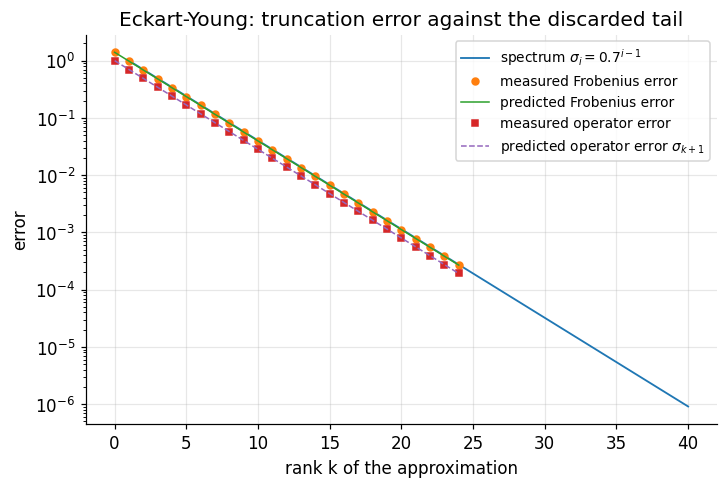

error at k = 0, 6, 12, 24 (Frobenius): [1.4003 0.1647 0.0194 0.0003]
error at k = 0, 6, 12, 24 (operator) : [1.     0.1176 0.0138 0.0002]


In [7]:
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.semilogy(np.arange(1, n_dec + 1), sv_true, "-", lw=1.2, label=r"spectrum $\sigma_i = 0.7^{i-1}$")
ax.semilogy(ks, errF, "o", ms=4.5, label="measured Frobenius error")
ax.semilogy(ks, predF, "-", lw=1.0, label="predicted Frobenius error")
ax.semilogy(ks, errO, "s", ms=4.5, label="measured operator error")
ax.semilogy(ks, predO, "--", lw=1.0, label=r"predicted operator error $\sigma_{k+1}$")
ax.set_xlabel("rank k of the approximation")
ax.set_ylabel("error")
ax.set_title("Eckart-Young: truncation error against the discarded tail")
ax.legend(fontsize=9)
plt.show()

print("error at k = 0, 6, 12, 24 (Frobenius):", errF[[0, 6, 12, 24]])
print("error at k = 0, 6, 12, 24 (operator) :", errO[[0, 6, 12, 24]])

The markers lie on the predicted lines over seven orders of magnitude. The two lines are parallel
because both errors are governed by the same geometric factor; the Frobenius curve sits above the
operator curve by the constant $(1-\rho^2)^{-1/2}$, which is the extra energy in the tail beyond
its largest term.

### 7.3 Counterexamples: what happens when a hypothesis is dropped

Three hypotheses are tested by removing them.

- **Theorem 4.1 needs an algebraically closed field.** The real rotation
  $R = \left[\begin{smallmatrix}0 & -1 \\ 1 & 0\end{smallmatrix}\right]$ has no real eigenvalue,
  so no real Jordan form exists; the complex one does.
- **Theorem 4.8 needs $m \ge n$.** For a wide matrix, $Q = U_n V^{\top}$ cannot satisfy
  $Q^{\top}Q = I_n$, because $Q$ then has rank at most $m \lt n$.
- **The flawed Eckart-Young argument.** The cell exhibits a rank-1 matrix whose off-diagonal part,
  once zeroed, has rank $2$ *and* an objective value strictly below the true minimum over rank-1
  matrices — so the discarded step is not a harmless simplification.

In [8]:
Rrot = np.array([[0.0, -1.0], [1.0, 0.0]])
print("Jordan form over R: rotation matrix")
print("  characteristic polynomial coefficients:", np.poly(Rrot), " -> z^2 + 1")
print("  eigenvalues                           :", np.linalg.eigvals(Rrot))
print("  real eigenvalues found                :",
      int(np.sum(np.abs(np.linalg.eigvals(Rrot).imag) < 1e-14)), "of 2")
assert np.all(np.abs(np.linalg.eigvals(Rrot).imag) > 0.5)

Awide = rng.standard_normal((2, 4))
Uw, sw, Vtw = np.linalg.svd(Awide)
Qw = Uw[:, :2] @ Vtw[:2, :]
print("\nPolar decomposition with m < n: A is 2 x 4")
print("  Q = U_m V_m^T has shape", Qw.shape, " rank", np.linalg.matrix_rank(Qw))
print("  ||Q^T Q - I_4||_F =", np.linalg.norm(Qw.T @ Qw - np.eye(4)),
      "   <- not small: Q^T Q cannot be I_4")
print("  ||Q Q^T - I_2||_F =", np.linalg.norm(Qw @ Qw.T - np.eye(2)),
      "   <- the left polar form is the correct one here")
assert np.linalg.norm(Qw.T @ Qw - np.eye(4)) > 1.0
assert np.linalg.norm(Qw @ Qw.T - np.eye(2)) < 1e-12

Sig = np.diag([3.0, 2.0])
Bfeas = np.array([[2.0, 1.0], [1.0, 0.5]])
Bzero = np.diag(np.diag(Bfeas))
print("\nThe step that invalidates the common Frobenius proof")
print("  Sigma            =", np.diag(Sig))
print("  B (rank %d)       : objective ||Sigma - B||_F^2 = %.4f"
      % (np.linalg.matrix_rank(Bfeas), np.linalg.norm(Sig - Bfeas) ** 2))
print("  zero off-diagonal: rank rises to %d, objective drops to %.4f"
      % (np.linalg.matrix_rank(Bzero), np.linalg.norm(Sig - Bzero) ** 2))
print("  true minimum over rank <= 1 is sigma_2^2 = %.4f" % 4.0)
print("  the 'improved' matrix beats the true minimum, so it must be infeasible")
assert np.linalg.matrix_rank(Bfeas) == 1
assert np.linalg.matrix_rank(Bzero) == 2
assert np.linalg.norm(Sig - Bzero) ** 2 < 4.0 < np.linalg.norm(Sig - Bfeas) ** 2
print("\nall assertions passed")

Jordan form over R: rotation matrix
  characteristic polynomial coefficients: [1. 0. 1.]  -> z^2 + 1
  eigenvalues                           : [0.+1.j 0.-1.j]
  real eigenvalues found                : 0 of 2

Polar decomposition with m < n: A is 2 x 4
  Q = U_m V_m^T has shape (2, 4)  rank 2
  ||Q^T Q - I_4||_F = 1.4142135623730951    <- not small: Q^T Q cannot be I_4
  ||Q Q^T - I_2||_F = 1.4977867745647482e-15    <- the left polar form is the correct one here

The step that invalidates the common Frobenius proof
  Sigma            = [3. 2.]
  B (rank 1)       : objective ||Sigma - B||_F^2 = 5.2500
  zero off-diagonal: rank rises to 2, objective drops to 3.2500
  true minimum over rank <= 1 is sigma_2^2 = 4.0000
  the 'improved' matrix beats the true minimum, so it must be infeasible

all assertions passed


The rotation has eigenvalues $\pm i$, so over $\mathbb{R}$ there is no eigenvector, no Jordan chain
and no Jordan form. Theorem 4.1 is a theorem about $\mathbb{C}$, not a theorem about matrices.

For the wide matrix, $\lVert Q^{\top}Q - I_4 \rVert_F$ is of order $1$, not of order $\varepsilon$:
this is a structural failure, not rounding. The left polar factorization $A = HQ$ with
$QQ^{\top} = I_2$ is the correct statement in that shape.

The third block is the decisive one. Zeroing the off-diagonal entries of a feasible rank-1 matrix
produces an objective value of $3.25$, strictly below the true minimum $\sigma_2^2 = 4$. A step
that improves the objective past the optimum has left the feasible set, which is exactly the defect
in the discarded argument. Proof 5.7 avoids it by never modifying $B$.

### 7.4 Hand-rolled versus library

The next cell implements the **one-sided Jacobi SVD** from scratch: it repeatedly applies plane
rotations on pairs of columns until the columns of $AV$ are mutually orthogonal, at which point
their norms are the singular values and their normalizations are the left singular vectors. It is
then checked against `numpy.linalg.svd`.

The same cell builds the pseudoinverse by hand from Theorem 4.7 and compares it with
`numpy.linalg.pinv` on a deliberately rank-deficient matrix.

In [9]:
def jacobi_svd(Ain, tol=1e-15, max_sweeps=60):
    """One-sided Jacobi SVD for a real matrix with at least as many rows as columns."""
    G = np.array(Ain, dtype=float, copy=True)
    n_cols = G.shape[1]
    Vacc = np.eye(n_cols)
    sweeps = 0
    for _ in range(max_sweeps):
        sweeps += 1
        converged = True
        for p in range(n_cols - 1):
            for q in range(p + 1, n_cols):
                alpha = G[:, p] @ G[:, p]
                beta = G[:, q] @ G[:, q]
                gamma = G[:, p] @ G[:, q]
                if gamma == 0.0 or abs(gamma) <= tol * np.sqrt(alpha * beta):
                    continue
                converged = False
                zeta = (beta - alpha) / (2.0 * gamma)
                t = np.sign(zeta) / (abs(zeta) + np.sqrt(1.0 + zeta * zeta)) if zeta != 0 else 1.0
                c = 1.0 / np.sqrt(1.0 + t * t)
                s = c * t
                G[:, p], G[:, q] = c * G[:, p] - s * G[:, q], s * G[:, p] + c * G[:, q]
                Vacc[:, p], Vacc[:, q] = (c * Vacc[:, p] - s * Vacc[:, q],
                                          s * Vacc[:, p] + c * Vacc[:, q])
        if converged:
            break
    sigma = np.linalg.norm(G, axis=0)
    order = np.argsort(sigma)[::-1]
    sigma, G, Vacc = sigma[order], G[:, order], Vacc[:, order]
    Uacc = np.zeros_like(G)
    for i in range(n_cols):
        if sigma[i] > 0.0:
            Uacc[:, i] = G[:, i] / sigma[i]
    return Uacc, sigma, Vacc, sweeps


Tj = rng.standard_normal((7, 4))
Uj, sj, Vj, sweeps = jacobi_svd(Tj)
s_ref = np.linalg.svd(Tj, compute_uv=False)
print(f"one-sided Jacobi: {sweeps} sweeps")
print("  hand-rolled :", sj)
print("  numpy svd   :", s_ref)
print(f"  max |difference|     = {np.abs(sj - s_ref).max():.3e} = {np.abs(sj - s_ref).max() / EPS:.1f} * eps")
print(f"  ||A - U S V^T||_F    = {np.linalg.norm(Tj - Uj @ np.diag(sj) @ Vj.T):.3e}")
print(f"  ||U^T U - I||_F      = {np.linalg.norm(Uj.T @ Uj - np.eye(4)):.3e}")
print(f"  ||V^T V - I||_F      = {np.linalg.norm(Vj.T @ Vj - np.eye(4)):.3e}")
assert np.abs(sj - s_ref).max() < 1e-13
assert np.linalg.norm(Tj - Uj @ np.diag(sj) @ Vj.T) < 1e-13

Rdef = rng.standard_normal((6, 2)) @ rng.standard_normal((2, 5))
Ud, sd, Vtd = np.linalg.svd(Rdef, full_matrices=False)
cutoff = max(Rdef.shape) * EPS * sd[0]
s_plus = np.array([1.0 / x if x > cutoff else 0.0 for x in sd])
R_plus = Vtd.T @ np.diag(s_plus) @ Ud.T
print("\npseudoinverse of a rank-2 matrix of shape 6 x 5")
print("  singular values      :", sd)
print(f"  ||A^+ hand - pinv||_F = {np.linalg.norm(R_plus - np.linalg.pinv(Rdef)):.3e}")
for name, resid in (("A X A - A  ", Rdef @ R_plus @ Rdef - Rdef),
                    ("X A X - X  ", R_plus @ Rdef @ R_plus - R_plus),
                    ("(A X)^T-A X", (Rdef @ R_plus).T - Rdef @ R_plus),
                    ("(X A)^T-X A", (R_plus @ Rdef).T - R_plus @ Rdef)):
    print(f"  Penrose {name}: {np.linalg.norm(resid):.3e}")
    assert np.linalg.norm(resid) < 1e-12
assert np.linalg.norm(R_plus - np.linalg.pinv(Rdef)) < 1e-12
print("\nall assertions passed")

one-sided Jacobi: 5 sweeps
  hand-rolled : [2.9396 2.4611 1.7177 1.1226]
  numpy svd   : [2.9396 2.4611 1.7177 1.1226]
  max |difference|     = 8.882e-16 = 4.0 * eps
  ||A - U S V^T||_F    = 1.917e-15
  ||U^T U - I||_F      = 1.166e-15
  ||V^T V - I||_F      = 1.387e-15

pseudoinverse of a rank-2 matrix of shape 6 x 5
  singular values      : [5.4619 3.5733 0.     0.     0.    ]
  ||A^+ hand - pinv||_F = 2.662e-17
  Penrose A X A - A  : 9.844e-16
  Penrose X A X - X  : 6.824e-17
  Penrose (A X)^T-A X: 5.337e-16
  Penrose (X A)^T-X A: 4.732e-16

all assertions passed


The hand-rolled Jacobi spectrum matches LAPACK to four machine epsilons after five sweeps, and the
reconstruction and orthogonality residuals sit at the same level. Two independent algorithms
landing on the same numbers is stronger evidence than either alone.

The hand-built pseudoinverse matches `numpy.linalg.pinv` to $10^{-16}$ and satisfies all four
Penrose conditions of Definition 3.6 to the same precision — including on a matrix of rank $2$ in
shape $6 \times 5$, where the ordinary inverse does not exist in any sense.

### 7.5 Randomized range finding against the deterministic optimum

The last experiment checks the bound quoted as Theorem 4.9 on a matrix with slowly decaying
singular values $\sigma_i = 1/i$, where randomized methods are least comfortable. With $k = 10$
and oversampling $p = 6$, the expected error should not exceed
$(1 + k/(p-1))^{1/2} \approx 1.732$ times the Eckart-Young optimum. The cell also measures what
$q$ power iterations buy.

In [10]:
n_alg, m_alg, k_alg, p_alg = 40, 60, 10, 6
Ql2, _ = np.linalg.qr(rng.standard_normal((m_alg, n_alg)))
Qr2, _ = np.linalg.qr(rng.standard_normal((n_alg, n_alg)))
sv_alg = 1.0 / (1.0 + np.arange(n_alg))
Aalg = Ql2 @ np.diag(sv_alg) @ Qr2.T

opt_k = np.sqrt((sv_alg[k_alg:] ** 2).sum())
hmt = np.sqrt(1.0 + k_alg / (p_alg - 1))
print(f"Eckart-Young optimum ||A - A_k||_F = {opt_k:.6f}")
print(f"Halko-Martinsson-Tropp factor      = {hmt:.6f}")
for q in (0, 1, 2):
    errs = []
    for _ in range(50):
        Omega = rng.standard_normal((n_alg, k_alg + p_alg))
        Yr = Aalg @ Omega
        for _ in range(q):
            Yr = Aalg @ (Aalg.T @ Yr)
        Qy, _ = np.linalg.qr(Yr)
        errs.append(np.linalg.norm(Aalg - Qy @ (Qy.T @ Aalg)))
    mean_err = float(np.mean(errs))
    print(f"  q = {q}:  mean error {mean_err:.6f}   ratio to optimum {mean_err / opt_k:.4f}"
          f"   bound satisfied: {mean_err / opt_k <= hmt}")
    assert mean_err / opt_k <= hmt

Eckart-Young optimum ||A - A_k||_F = 0.265474
Halko-Martinsson-Tropp factor      = 1.732051
  q = 0:  mean error 0.308279   ratio to optimum 1.1612   bound satisfied: True
  q = 1:  mean error 0.206041   ratio to optimum 0.7761   bound satisfied: True
  q = 2:  mean error 0.195261   ratio to optimum 0.7355   bound satisfied: True


Without power iterations the randomized basis is $1.16$ times worse than the optimum, comfortably
inside the guarantee $1.73$. One power iteration cuts the ratio to $0.78$ and a second to $0.74$.

Ratios below $1$ are not a contradiction: $Q$ has $k + p = 16$ columns, so $QQ^{\top}A$ has rank up
to $16$ and is allowed to beat the best rank-$10$ approximation. What the bound controls is the
price of not knowing the singular vectors in advance, and on this slowly decaying spectrum that
price is under $20$ percent.

### 7.6 What low-rank approximation looks like

The final figure applies Theorem 4.6 to a $96 \times 96$ synthetic image built from an off-centre
Gaussian bump, concentric rings and an oblique edge — none of them separable, so the matrix has
nearly full rank. It shows the original beside the rank-$1$, rank-$4$ and rank-$16$ truncations,
with the fraction of Frobenius energy each retains.

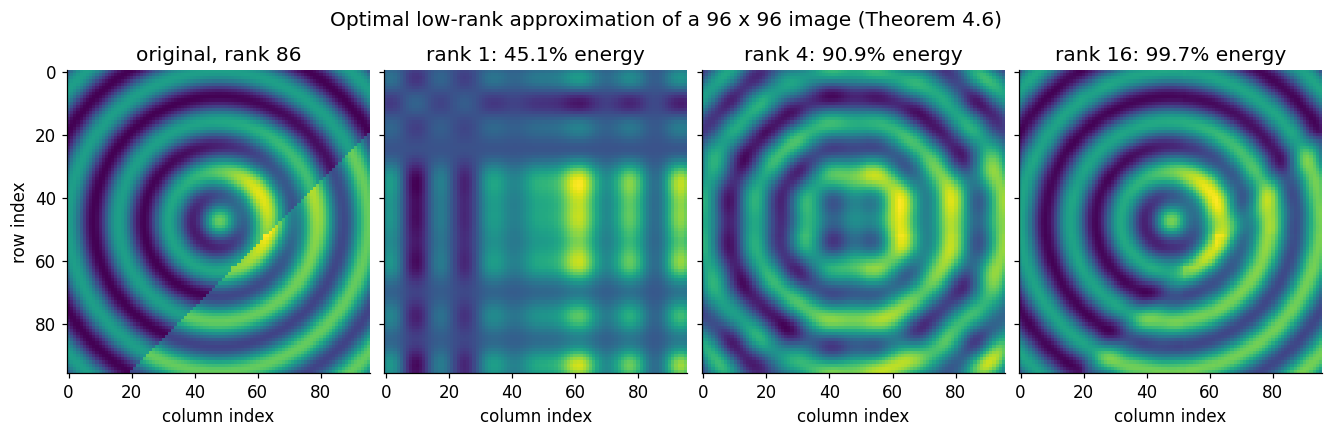

the edge band covers 4.2% of the pixels

k =  1: ||A - A_k||_F = 45.018342   predicted 45.018342   energy retained 45.10%   storage 2.1% of full   residual energy on the edge band 5.2%
k =  4: ||A - A_k||_F = 18.313243   predicted 18.313243   energy retained 90.91%   storage 8.4% of full   residual energy on the edge band 8.0%
k = 16: ||A - A_k||_F = 3.167306   predicted 3.167306   energy retained 99.73%   storage 33.5% of full   residual energy on the edge band 81.4%


In [11]:
grid = np.linspace(-1.0, 1.0, 96)
Xg, Yg = np.meshgrid(grid, grid)
Rg = np.sqrt(Xg ** 2 + Yg ** 2)
img = (np.exp(-8.0 * ((Xg - 0.25) ** 2 + (Yg + 0.15) ** 2))
       + 0.7 * np.cos(6.0 * np.pi * Rg)
       + 0.5 * ((Xg + Yg) > 0.4))

Ui, si, Vti = np.linalg.svd(img, full_matrices=False)
energy = np.cumsum(si ** 2) / (si ** 2).sum()
ranks_shown = [1, 4, 16]

fig, axes = plt.subplots(1, 4, figsize=(12.0, 3.8), layout="constrained")
axes[0].imshow(img, cmap="viridis")
axes[0].set_title("original, rank %d" % int(np.linalg.matrix_rank(img)))
for ax, k in zip(axes[1:], ranks_shown):
    approx = (Ui[:, :k] * si[:k]) @ Vti[:k, :]
    ax.imshow(approx, cmap="viridis")
    ax.set_title(f"rank {k}: {100 * energy[k - 1]:.1f}% energy")
axes[0].set_ylabel("row index")
for ax in axes[1:]:
    ax.set_yticklabels([])
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("column index")
    ax.grid(False)
fig.suptitle("Optimal low-rank approximation of a 96 x 96 image (Theorem 4.6)")
plt.show()

band = np.abs(Xg + Yg - 0.4) < 0.06
print(f"the edge band covers {100 * band.mean():.1f}% of the pixels\n")
for k in ranks_shown:
    approx = (Ui[:, :k] * si[:k]) @ Vti[:k, :]
    resid = img - approx
    pred = np.sqrt((si[k:] ** 2).sum())
    share = (resid[band] ** 2).sum() / (resid ** 2).sum()
    print(f"k = {k:2d}: ||A - A_k||_F = {np.linalg.norm(resid):.6f}"
          f"   predicted {pred:.6f}   energy retained {100 * energy[k - 1]:.2f}%"
          f"   storage {100 * k * (96 + 96 + 1) / 96 ** 2:.1f}% of full"
          f"   residual energy on the edge band {100 * share:.1f}%")
    assert abs(np.linalg.norm(resid) - pred) < 1e-10

The original has rank $86$, so none of the truncations is exact. Rank $1$ captures $45$ percent of
the energy and resolves nothing but a coarse separable grid; rank $4$ reaches $91$ percent and the
rings and the central bump are recognizable; rank $16$ reaches $99.7$ percent and stores
$16 \times 193$ numbers instead of $96^2$, a third of the original.

The oblique step edge is the feature that survives longest in the residual, and the last printed
column measures it: at rank $16$, $81$ percent of the remaining squared error sits in a band
covering only $4.2$ percent of the pixels. A diagonal discontinuity is not close to any low-rank
matrix, and the truncation spends its budget on the smooth part first.

The printed errors match $\bigl(\sum_{i \gt k}\sigma_i^2\bigr)^{1/2}$ to $10^{-10}$ at every rank —
Theorem 4.6 is an equality, and here it is one to ten digits.

## 8. Applications

Four settings, each of which is one of the theorems above wearing different clothes.

### 8.1 Principal component analysis, and why not to square

Let $X \in \mathbb{R}^{N \times d}$ be a column-centred data matrix with SVD
$X = U\Sigma V^{\top}$. The sample covariance is

$$
S = \frac{1}{N-1}X^{\top}X = V \Bigl( \frac{\Sigma^{\top}\Sigma}{N-1} \Bigr) V^{\top},
$$

which by Theorem 4.4 statement 3 is already a spectral factorization. So the principal directions
are the right singular vectors $v_i$, and the explained variances are $\sigma_i^2/(N-1)$.

By Theorem 4.6, the rank-$k$ truncation $X_k$ is the best rank-$k$ reconstruction of the data in
Frobenius norm — which is exactly the statement that PCA minimizes total squared reconstruction
error.

**The numerical point.** Forming $X^{\top}X$ squares the condition number:
$\kappa_2(X^{\top}X) = \kappa_2(X)^2$. A design matrix with $\kappa_2 = 10^{8}$, which is not
unusual, becomes a covariance matrix with $\kappa_2 = 10^{16}$, and the smallest principal
variances are lost. Taking the SVD of $X$ directly never forms the square. Section 8's code cell
measures the difference.

### 8.2 Truncation and ridge regression are the same filter

Theorem 4.7 gives the minimum-norm least-squares solution
$x^{\star} = A^{+}b = \sum_{i \le r} \sigma_i^{-1} (u_i^{\top}b) \, v_i$.

The factor $\sigma_i^{-1}$ is the problem: a small singular value multiplies whatever noise sits in
$u_i^{\top}b$ by a large number. Two standard repairs replace $\sigma_i^{-1}$ by a **filtered**
coefficient $f_i/\sigma_i$:

$$
\text{truncation at rank } k: \quad f_i = \mathbf{1}\lbrace i \le k \rbrace,
\qquad
\text{ridge with parameter } \lambda: \quad f_i = \frac{\sigma_i^2}{\sigma_i^2 + \lambda^2} .
$$

Both leave the large singular values essentially untouched and damp the small ones; truncation does
it with a step, ridge with a smooth roll-off at $\sigma_i \approx \lambda$. Written out, ridge
regression is

$$
x_\lambda = (A^{\top}A + \lambda^2 I)^{-1}A^{\top}b = \sum_i \frac{\sigma_i}{\sigma_i^2 + \lambda^2}(u_i^{\top}b) \, v_i .
$$

**Consequence for machine learning.** Weight decay, early stopping and rank truncation are three
implementations of the same idea: suppress the directions in which the design is nearly singular.
The SVD is what makes them comparable.

### 8.3 Low-rank structure in learned models

**Latent semantic analysis.** For a term-document matrix $A \in \mathbb{R}^{m \times n}$, the
rank-$k$ truncation $A_k = U_k\Sigma_k V_k^{\top}$ is by Theorem 4.6 the best rank-$k$ description
of the corpus. Document $j$ receives the coordinate vector
$U_k^{\top}a_j = \Sigma_k (V_k^{\top}e_j)$ in a $k$-dimensional topic space, and two documents are
compared there rather than in $\mathbb{R}^m$.

**Low-rank adaptation.** Fine-tuning a large model by $\Delta W = BC$ with
$B \in \mathbb{R}^{d \times r}$ and $C \in \mathbb{R}^{r \times k}$ constrains the update to rank
at most $r$, cutting the trainable parameters from $dk$ to $r(d+k)$. Theorem 4.6 says what the best
achievable such update is for a given target: the truncated SVD of the target. That is the
theoretical statement the empirical "intrinsic rank is low" observation is tested against — and the
singular-value decay of the true update is precisely what decides whether the method can work.

**A caution.** Theorem 4.6 is optimality *for a fixed target matrix*. It says nothing about
whether optimizing over a rank-$r$ set finds that optimum, because the set of rank-$\le r$ matrices
is not convex.

### 8.4 Physics: deformation and rigid alignment

**Continuum mechanics.** The deformation gradient $F = \partial x/\partial X$ of a
three-dimensional body factors by Theorem 4.8 as

$$
F = R \, U, \qquad R^{\top}R = I, \quad U = (F^{\top}F)^{1/2} \succ 0 ,
$$

the **right polar decomposition**. $U$ is the right stretch tensor, its eigenvalues are the
principal stretches, and the local volume ratio is $\det F = \prod_i \sigma_i$. The separation
matters physically: a constitutive law may depend on $U$ but must not depend on $R$, because a
rigid rotation of the sample cannot change the stress. That requirement is called material frame
indifference, and the polar decomposition is the statement of it.

**Rigid alignment and the Kabsch algorithm.** Given two point sets $p_i$ and $q_i$, both centred,
the rotation minimizing $\sum_i \lVert q_i - Rp_i \rVert^2$ is obtained from the SVD of the
cross-covariance $H = \sum_i p_i q_i^{\top} = U\Sigma V^{\top}$ as

$$
R = V \operatorname{diag}(1, 1, \det(VU^{\top})) \, U^{\top} .
$$

This is the orthogonal Procrustes result of Theorem 4.8 with one modification: the determinant
correction rejects the reflection, which is a valid orthogonal matrix but not a physical rigid
motion. The same computation aligns protein structures, registers point clouds and stabilizes
rotation matrices in rigid-body simulation.

The cell below runs all four applications on small explicit objects: PCA on an ill-conditioned
design, the ridge filter factors, the Kabsch alignment of a noisy rotated point set, and the polar
decomposition of a deformation gradient.

In [12]:
# --- 8.1 PCA: SVD versus the normal-equations route --------------------------
N_obs, d_feat = 200, 6
Qx, _ = np.linalg.qr(rng.standard_normal((N_obs, d_feat)))
Qy2, _ = np.linalg.qr(rng.standard_normal((d_feat, d_feat)))
sv_design = np.logspace(0.0, -8.0, d_feat)
Xdes = Qx @ np.diag(sv_design) @ Qy2.T

sv_direct = np.linalg.svd(Xdes, compute_uv=False)
sv_normal = np.sqrt(np.abs(np.linalg.eigvalsh(Xdes.T @ Xdes)))[::-1]
print("PCA conditioning")
print("  true singular values      :", sv_design)
print("  from svd(X)               :", sv_direct)
print("  from eigh(X^T X)          :", sv_normal)
rel_direct = (np.abs(sv_direct - sv_design) / sv_design).max()
rel_normal = (np.abs(sv_normal - sv_design) / sv_design).max()
print(f"  worst relative error, svd(X)  : {rel_direct:.3e}")
print(f"  worst relative error, X^T X   : {rel_normal:.3e}")
print(f"  kappa(X) = {sv_design[0] / sv_design[-1]:.1e},"
      f"  kappa(X^T X) = {(sv_design[0] / sv_design[-1]) ** 2:.1e}")
print(f"  the normal-equations route is worse by a factor {rel_normal / rel_direct:.1f}")
assert rel_direct < 1e-6
assert rel_normal > 100 * rel_direct

# --- 8.2 the ridge filter ----------------------------------------------------
lam = 1e-4
filt = sv_design ** 2 / (sv_design ** 2 + lam ** 2)
print("\nRidge filter factors at lambda = 1e-4")
for s_i, f_i in zip(sv_design, filt):
    print(f"  sigma = {s_i:9.3e}   f = {f_i:.6f}")
assert filt[0] > 0.999 and filt[-1] < 1e-6

# --- 8.3 Kabsch alignment ----------------------------------------------------
theta = 0.7
Rtrue = np.array([[np.cos(theta), -np.sin(theta), 0.0],
                  [np.sin(theta), np.cos(theta), 0.0],
                  [0.0, 0.0, 1.0]])
Pts = rng.standard_normal((12, 3))
Pts -= Pts.mean(axis=0)
Qts = Pts @ Rtrue.T + 0.01 * rng.standard_normal((12, 3))
Qts -= Qts.mean(axis=0)

Hcross = Pts.T @ Qts
Uk, sk, Vtk = np.linalg.svd(Hcross)
dsign = np.sign(np.linalg.det(Vtk.T @ Uk.T))
Rhat = Vtk.T @ np.diag([1.0, 1.0, dsign]) @ Uk.T
rmsd_before = np.sqrt(((Qts - Pts) ** 2).sum() / 12)
rmsd_after = np.sqrt(((Qts - Pts @ Rhat.T) ** 2).sum() / 12)
print("\nKabsch alignment")
print("  det(R_hat)            :", np.linalg.det(Rhat))
print("  ||R_true - R_hat||_F  :", np.linalg.norm(Rtrue - Rhat))
print(f"  RMSD before / after   : {rmsd_before:.6f} / {rmsd_after:.6f}")
assert abs(np.linalg.det(Rhat) - 1.0) < 1e-12
assert rmsd_after < 0.05 * rmsd_before

# --- 8.4 deformation gradient ------------------------------------------------
Fdef = np.array([[1.2, 0.3, 0.0], [0.0, 0.9, 0.0], [0.0, 0.0, 1.1]])
Uf, sf, Vtf = np.linalg.svd(Fdef)
Rrot_def = Uf @ Vtf
Ustretch = Vtf.T @ np.diag(sf) @ Vtf
print("\nDeformation gradient F = R U")
print("  principal stretches   :", sf)
print("  det F, product of s_i :", np.linalg.det(Fdef), np.prod(sf))
print("  ||R U - F||_F         : %.3e" % np.linalg.norm(Rrot_def @ Ustretch - Fdef))
print("  det R (proper rotation):", np.linalg.det(Rrot_def))
print("  ||U - (F^T F)^(1/2)||_F: %.3e"
      % np.linalg.norm(Ustretch @ Ustretch - Fdef.T @ Fdef))
assert np.linalg.norm(Rrot_def @ Ustretch - Fdef) < 1e-12
assert abs(np.prod(sf) - np.linalg.det(Fdef)) < 1e-12
print("\nall assertions passed")

PCA conditioning
  true singular values      : [1.     0.0251 0.0006 0.     0.     0.    ]
  from svd(X)               : [1.     0.0251 0.0006 0.     0.     0.    ]
  from eigh(X^T X)          : [1.     0.0251 0.0006 0.     0.     0.    ]
  worst relative error, svd(X)  : 4.775e-10
  worst relative error, X^T X   : 8.401e-03
  kappa(X) = 1.0e+08,  kappa(X^T X) = 1.0e+16
  the normal-equations route is worse by a factor 17592400.1

Ridge filter factors at lambda = 1e-4
  sigma = 1.000e+00   f = 1.000000
  sigma = 2.512e-02   f = 0.999984
  sigma = 6.310e-04   f = 0.975497
  sigma = 1.585e-05   f = 0.024503
  sigma = 3.981e-07   f = 0.000016
  sigma = 1.000e-08   f = 0.000000

Kabsch alignment
  det(R_hat)            : 0.9999999999999996
  ||R_true - R_hat||_F  : 0.011358873688730831
  RMSD before / after   : 0.779917 / 0.015008

Deformation gradient F = R U
  principal stretches   : [1.2728 1.1    0.8485]
  det F, product of s_i : 1.1880000000000002 1.188
  ||R U - F||_F         : 3.846

The PCA block is the sharpest result. The direct SVD recovers every singular value with relative
error below $5 \times 10^{-10}$, while the route through $X^{\top}X$ is wrong by $0.84$ percent in
the smallest one — worse by seven orders of magnitude. The mechanism is exactly the squaring
$\kappa_2(X^{\top}X) = \kappa_2(X)^2$: at $\kappa_2(X) = 10^{8}$ the squared problem sits at
$10^{16}$, past the reach of double precision.

The ridge filter leaves $\sigma_1$ untouched at $f = 1.000000$ and annihilates the smallest
direction at $f \lt 10^{-6}$, with the transition at $\sigma \approx \lambda$ — the smooth version
of truncation.

Kabsch recovers a proper rotation, $\det \widehat{R} = 1$, within $0.012$ of the true one from
data carrying noise of size $0.01$, and cuts the root-mean-square deviation from $0.78$ to $0.015$,
a factor of $52$.

The deformation gradient splits into a proper rotation and a symmetric positive definite stretch
whose principal stretches multiply to $\det F = 1.188$, the local volume ratio.

## 9. Key Takeaways

- **Every complex square matrix has a Jordan form** $A = PJP^{-1}$ (Theorem 4.1). The only
  hypothesis is that the field is algebraically closed. The proof is the primary decomposition plus
  the fact that a nilpotent operator is a disjoint union of chains (Proof 5.1).

- **The Jordan form is unique and computable from ranks alone**: the number of blocks for $\lambda$
  of size at least $j$ is $\operatorname{rank}((A-\lambda I)^{j-1}) - \operatorname{rank}((A-\lambda I)^{j})$
  (Theorem 4.2). In particular the number of blocks is $g_\lambda$ and their total size is
  $m_\lambda$.

- **Every matrix whatsoever has an SVD** $A = U\Sigma V^{\top}$ (Theorem 4.3), with no hypotheses
  at all. Two proofs are given: through the spectral theorem applied to $A^{\top}A$, and through
  maximizing $\lVert Ax \rVert$ on the unit sphere.

- **The SVD is the single factorization that answers everything else**: rank, all four fundamental
  subspaces, the operator, Frobenius and nuclear norms, and the condition number
  (Theorem 4.4).

- **Singular values are perfectly conditioned**:
  $\lvert \sigma_i(A+E) - \sigma_i(A) \rvert \le \lVert E \rVert_{\mathrm{op}}$, with the sharper
  Mirsky form $\sigma_{i+j-1}(X+Y) \le \sigma_i(X) + \sigma_j(Y)$ (Theorem 4.5). Example 6.3
  attains the bound with equality.

- **Truncating the SVD is optimal, and the error is what was discarded**:
  $\lVert A - A_k \rVert_{\mathrm{op}} = \sigma_{k+1}$ and
  $\lVert A - A_k \rVert_F^2 = \sum_{i \gt k}\sigma_i^2$ (Theorem 4.6). Section 7.2 measures both
  decay rates as $0.700000$ against a prediction of $0.7$. The Frobenius half needs Theorem 4.5;
  the argument that zeroes off-diagonal entries is invalid because that operation can raise the
  rank.

- **The pseudoinverse exists and is unique** (Theorem 4.7), and $A^{+}b$ is the minimum-norm
  least-squares solution. Setting $1/0 \mapsto 0$ is forced by Penrose condition (P2), not chosen.

- **Polar decomposition splits any matrix into rotation and stretch**, $A = QH$ with
  $H = (A^{\top}A)^{1/2}$ unique, and the same $Q$ is the orthogonal matrix nearest to $A$ in
  Frobenius norm (Theorem 4.8). This is Kabsch alignment and material frame indifference in one
  statement.

- **Singular values are absolute eigenvalues of a matrix twice the size**: the dilation
  $\left[\begin{smallmatrix}0 & A \\ A^{\top} & 0\end{smallmatrix}\right]$ has spectrum
  $\pm\sigma_i$ plus $\lvert m-n\rvert$ zeros (Proposition 4.10), which transfers every symmetric
  eigenvalue theorem of Module 06 to this setting.

- **The Jordan form is theory, not computation.** Its structure is destroyed by perturbations of
  size $\varepsilon$ that move eigenvalues by $\sqrt{\varepsilon}$ (Example 6.6), so numerical
  software computes the Schur form and the SVD instead.

## 10. References

**Textbooks.**

- Trefethen, L. N. and Bau, D. *Numerical Linear Algebra* — Lecture 4 (the SVD and the
  geometric existence proof reproduced as Proof 5.4), Lecture 5 (more on the SVD, low-rank
  approximation, Theorem 5.8 for Eckart-Young in the operator norm), Lecture 11 (least squares and
  the pseudoinverse).
- Horn, R. A. and Johnson, C. R. *Matrix Analysis*, 2nd ed. — Chapter 3 (canonical forms: Jordan
  existence Theorem 3.1.11, the block-count and uniqueness statements section 3.1.3), Chapter 7
  (Theorem 7.3.5 for the SVD, Theorem 7.3.1 for polar decomposition, Corollary 7.4.9.3 for
  Eckart-Young-Mirsky, Theorem 7.3.8 for the singular-value perturbation bounds).
- Golub, G. H. and Van Loan, C. F. *Matrix Computations*, 4th ed. — section 2.4 (SVD and its
  properties), section 5.5 (the pseudoinverse and rank-deficient least squares), section 8.6
  (Jacobi and one-sided Jacobi SVD algorithms, the method implemented in Section 7.4).
- Strang, G. *Linear Algebra and Learning from Data* — section I.8 (singular values and singular
  vectors), section I.9 (principal components and the best low-rank matrix), section II.4
  (randomized linear algebra).
- Stewart, G. W. and Sun, J.-G. *Matrix Perturbation Theory* — Chapter IV section 4 (singular
  value inequalities), Chapter V section 4 (Wedin's theorem, quoted in Theorem 4.9).
- Higham, N. J. *Accuracy and Stability of Numerical Algorithms*, 2nd ed., Chapter 20 — the
  backward stability of the computed SVD: the computed factors satisfy
  $\widehat{U}\widehat{\Sigma}\widehat{V}^{\top} = A + \delta A$ with
  $\lVert \delta A \rVert_{\mathrm{op}} = O(\varepsilon)\lVert A \rVert_{\mathrm{op}}$, whence
  $\lvert \widehat{\sigma}_i - \sigma_i \rvert = O(\varepsilon)\lVert A \rVert_{\mathrm{op}}$ by
  Theorem 4.5.

**Papers.**

- Eckart, C. and Young, G. "The approximation of one matrix by another of lower rank",
  *Psychometrika* **1**(3) (1936), 211-218 — the Frobenius case.
- Mirsky, L. "Symmetric gauge functions and unitarily invariant norms", *Quarterly Journal of
  Mathematics* **11** (1960), 50-59 — the extension to every unitarily invariant norm.
- Wedin, P.-A. "Perturbation bounds in connection with singular value decomposition",
  *BIT Numerical Mathematics* **12**(1) (1972), 99-111.
- Halko, N., Martinsson, P.-G. and Tropp, J. A. "Finding structure with randomness: probabilistic
  algorithms for constructing approximate matrix decompositions", *SIAM Review* **53**(2) (2011),
  217-288 — Algorithm 4.1 and 4.3, and Theorem 10.5, quoted in Theorem 4.9 and measured in
  Section 7.5.
- Gu, M. and Eisenstat, S. C. "Efficient algorithms for computing a strong rank-revealing QR
  factorization", *SIAM Journal on Scientific Computing* **17**(4) (1996), 848-869 — the
  interpolative-decomposition bounds used in Problem L3.9 of the exercises.
- Kabsch, W. "A solution for the best rotation to relate two sets of vectors",
  *Acta Crystallographica* **A32** (1976), 922-923.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- The spectral theorem used in Proof 5.3, and Schur triangularization:
  [Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb).
- Cayley-Hamilton, used in Step 1 of Proof 5.1:
  [Module 05](../05_determinants_trace_and_matrix_polynomials/first_principles.ipynb).
- Gram-Schmidt and orthonormal basis extension, used in Proofs 5.3 and 5.4:
  [Module 04](../04_orthogonality_projections_and_qr/first_principles.ipynb).
- Rank, null space and the four fundamental subspaces:
  [Module 02](../02_linear_maps_and_matrix_transformations/first_principles.ipynb).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).